In [275]:
import json
from ast import literal_eval
from fnmatch import fnmatch
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import pandas as pd

In [276]:
no_system_file = "/home/joselu/Universidad/Doctorado/GENIO/tmp/10_48/insect_xheep_nsga2_population_search_genio_no_xheep/statistics/individuals.csv"
no_traffic_file = "/home/joselu/Universidad/Doctorado/GENIO/tmp/10_48/insect_xheep_nsga2_population_search_genio_trans_mem_mem/statistics/individuals.csv"
sequential_traffic_file = "/home/joselu/Universidad/Doctorado/GENIO/tmp/10_48/insect_xheep_nsga2_population_search_genio_trans_mem_mem_sequential_saturation/statistics/individuals.csv"
periodic_traffic_file = "/home/joselu/Universidad/Doctorado/GENIO/tmp/10_48/insect_xheep_nsga2_population_search_genio_trans_mem_mem_periodic_saturation/statistics/individuals.csv"
burst_traffic_file = "/home/joselu/Universidad/Doctorado/GENIO/tmp/10_48/insect_xheep_nsga2_population_search_genio_trans_mem_mem_burst_saturation/statistics/individuals.csv"
bernoulli_traffic_file = "/home/joselu/Universidad/Doctorado/GENIO/tmp/10_48/insect_xheep_nsga2_population_search_genio_trans_mem_mem_bernoulli_saturation/statistics/individuals.csv"

no_system_dataframe = pd.read_csv(no_system_file)
no_traffic_dataframe = pd.read_csv(no_traffic_file)
sequential_traffic_dataframe = pd.read_csv(sequential_traffic_file)
periodic_traffic_dataframe = pd.read_csv(periodic_traffic_file)
burst_traffic_dataframe = pd.read_csv(burst_traffic_file)
bernoulli_traffic_dataframe = pd.read_csv(bernoulli_traffic_file)

no_system_dataframe = no_system_dataframe[no_system_dataframe["evaluation_status"]=="success"]
no_traffic_dataframe = no_traffic_dataframe[no_traffic_dataframe["evaluation_status"]=="success"]
sequential_traffic_dataframe = sequential_traffic_dataframe[sequential_traffic_dataframe["evaluation_status"]=="success"]
periodic_traffic_dataframe = periodic_traffic_dataframe[periodic_traffic_dataframe["evaluation_status"]=="success"]
burst_traffic_dataframe = burst_traffic_dataframe[burst_traffic_dataframe["evaluation_status"]=="success"]
bernoulli_traffic_dataframe = bernoulli_traffic_dataframe[bernoulli_traffic_dataframe["evaluation_status"]=="success"]

In [277]:
no_traffic_file_2 = "/home/joselu/Universidad/Doctorado/GENIO/tmp/insect_xheep_nsga2_population_search_genio_trans_mem_mem/statistics/individuals.csv"

no_traffic_dataframe_2 = pd.read_csv(no_traffic_file_2)

no_traffic_dataframe_2 = no_traffic_dataframe_2[no_traffic_dataframe_2["evaluation_status"]=="success"]

In [278]:
def parse_algorithm_solutions(log_file: str | Path) -> dict[str, list[list[int]]]:
    """Parse the BEST genotypes grouped by test from an exploration log."""
    solutions_by_test = {}
    expected_counts = {}
    current_test = None

    with Path(log_file).open(encoding="utf-8") as log:
        for line_number, raw_line in enumerate(log, start=1):
            line = raw_line.strip()
            if line.startswith("Test: "):
                current_test = line.removeprefix("Test: ").strip()
                if current_test in solutions_by_test:
                    raise ValueError(f"Test duplicado en la línea {line_number}: {current_test}")
                solutions_by_test[current_test] = []
            elif line.startswith("Algorithm solutions: "):
                if current_test is None:
                    raise ValueError(f"Conteo sin test en la línea {line_number}")
                expected_counts[current_test] = int(
                    line.removeprefix("Algorithm solutions: ")
                )
            elif line.startswith("BEST "):
                if current_test is None:
                    raise ValueError(f"Solución sin test en la línea {line_number}")
                try:
                    _, _, encoded_genotype = line.split(maxsplit=2)
                    genotype = literal_eval(encoded_genotype)
                except (SyntaxError, ValueError) as error:
                    raise ValueError(
                        f"Solución inválida en la línea {line_number}: {line}"
                    ) from error
                if not isinstance(genotype, tuple) or not all(
                    isinstance(value, int) for value in genotype
                ):
                    raise ValueError(f"Genotipo inválido en la línea {line_number}")
                solutions_by_test[current_test].append(list(genotype))

    for test, solutions in solutions_by_test.items():
        expected = expected_counts.get(test)
        if expected is None:
            raise ValueError(f"No se encontró el conteo de soluciones para {test}")
        if len(solutions) != expected:
            raise ValueError(
                f"{test}: se esperaban {expected} soluciones y se encontraron {len(solutions)}"
            )

    return solutions_by_test



In [279]:
output_log_file = "/home/joselu/Universidad/Doctorado/GENIO/tmp/10_48/Output.log"


algorithm_solutions_by_test = parse_algorithm_solutions(output_log_file)

for key in algorithm_solutions_by_test.keys():
    print(key)
    print(algorithm_solutions_by_test[key])

genio_no_system
[[0, 1, 14, 0, 5, 0, 0, 0, 0, 4, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0], [0, 1, 14, 0, 5, 0, 0, 0, 0, 4, 0, 0, 1, 0, 1, 0, 0, 2, 2, 0], [0, 1, 14, 0, 5, 0, 0, 0, 0, 4, 0, 1, 0, 0, 1, 0, 0, 0, 2, 0], [0, 1, 14, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 1, 0], [0, 1, 15, 0, 0, 13, 0, 0, 0, 4, 0, 1, 0, 0, 1, 0, 0, 3, 0, 0], [0, 1, 14, 0, 0, 0, 0, 0, 0, 4, 0, 1, 0, 0, 1, 0, 0, 1, 3, 0], [0, 1, 14, 0, 0, 0, 0, 0, 0, 2, 0, 1, 0, 0, 0, 0, 0, 0, 3, 0], [0, 1, 14, 0, 5, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 2, 0, 0], [0, 1, 14, 0, 0, 0, 0, 0, 0, 4, 0, 0, 1, 0, 1, 0, 0, 3, 2, 0], [0, 0, 4, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0]]
genio_trans_mem_mem
[[0, 1, 13, 5, 6, 4, 0, 0, 0, 2, 0, 0, 1, 0, 2, 0, 0, 1, 0, 0], [0, 1, 13, 5, 6, 4, 0, 0, 0, 2, 0, 0, 1, 0, 2, 0, 0, 1, 1, 0], [0, 1, 13, 5, 0, 0, 0, 0, 0, 2, 0, 1, 1, 0, 1, 0, 0, 1, 3, 0], [0, 0, 4, 0, 0, 0, 0, 0, 0, 4, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0], [0, 1, 13, 0, 0, 0, 0, 0, 0, 2, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0], [0, 1, 14, 0, 0, 0

In [280]:
no_system_algorithm_solutions = [[0, 1, 14, 0, 5, 0, 0, 0, 0, 4, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0], [0, 1, 14, 0, 5, 0, 0, 0, 0, 4, 0, 0, 1, 0, 1, 0, 0, 2, 2, 0], [0, 1, 14, 0, 5, 0, 0, 0, 0, 4, 0, 1, 0, 0, 1, 0, 0, 0, 2, 0], [0, 1, 14, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 1, 0], [0, 1, 15, 0, 0, 13, 0, 0, 0, 4, 0, 1, 0, 0, 1, 0, 0, 3, 0, 0], [0, 1, 14, 0, 0, 0, 0, 0, 0, 4, 0, 1, 0, 0, 1, 0, 0, 1, 3, 0], [0, 1, 14, 0, 0, 0, 0, 0, 0, 2, 0, 1, 0, 0, 0, 0, 0, 0, 3, 0], [0, 1, 14, 0, 5, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 2, 0, 0], [0, 1, 14, 0, 0, 0, 0, 0, 0, 4, 0, 0, 1, 0, 1, 0, 0, 3, 2, 0], [0, 0, 4, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0]]
no_traffic_algorithm_solutions = [[0, 1, 13, 5, 6, 4, 0, 0, 0, 2, 0, 0, 1, 0, 2, 0, 0, 1, 0, 0], [0, 1, 13, 5, 6, 4, 0, 0, 0, 2, 0, 0, 1, 0, 2, 0, 0, 1, 1, 0], [0, 1, 13, 5, 0, 0, 0, 0, 0, 2, 0, 1, 1, 0, 1, 0, 0, 1, 3, 0], [0, 0, 4, 0, 0, 0, 0, 0, 0, 4, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0], [0, 1, 13, 0, 0, 0, 0, 0, 0, 2, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0], [0, 1, 14, 0, 0, 0, 0, 0, 0, 2, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0], [0, 1, 14, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 2, 0]]
sequential_traffic_algorithm_solutions = [[2, 0, 16, 3, 0, 1, 0, 0, 0, 2, 0, 1, 0, 0, 1, 0, 0, 2, 2, 0], [2, 0, 16, 3, 0, 1, 0, 0, 0, 2, 0, 1, 0, 0, 0, 0, 0, 3, 2, 0], [1, 0, 4, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 2, 1, 0], [1, 0, 4, 0, 0, 0, 0, 0, 0, 4, 0, 1, 1, 0, 0, 0, 0, 2, 2, 0], [2, 1, 9, 5, 0, 1, 0, 0, 0, 4, 0, 1, 0, 0, 0, 0, 0, 2, 1, 0], [1, 1, 16, 0, 0, 3, 0, 0, 0, 4, 0, 0, 0, 0, 2, 0, 0, 3, 3, 0], [1, 1, 14, 0, 0, 5, 0, 0, 0, 3, 0, 1, 1, 0, 2, 0, 0, 0, 2, 0], [1, 1, 14, 0, 0, 0, 0, 0, 0, 2, 0, 1, 1, 0, 2, 0, 0, 2, 1, 0], [2, 0, 16, 3, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 3, 0], [2, 1, 14, 0, 0, 0, 0, 0, 0, 3, 0, 1, 1, 0, 2, 0, 0, 0, 2, 0], [1, 0, 4, 0, 0, 0, 0, 0, 0, 3, 0, 1, 1, 0, 1, 0, 0, 1, 3, 0]]
periodic_traffic_algorithm_solutions = [[2, 0, 12, 2, 5, 0, 0, 0, 0, 3, 0, 0, 1, 0, 1, 0, 0, 3, 3, 0], [2, 1, 9, 0, 0, 0, 0, 0, 0, 4, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0], [1, 0, 4, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 3, 3, 0], [2, 0, 11, 2, 5, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 2, 0], [1, 1, 14, 0, 0, 0, 0, 0, 0, 4, 0, 1, 1, 0, 1, 0, 0, 3, 1, 0], [2, 1, 9, 0, 0, 0, 0, 0, 0, 4, 0, 1, 0, 0, 2, 0, 0, 0, 1, 0]]
burst_traffic_algorithm_solutions = [[2, 0, 13, 0, 0, 2, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 3, 2, 0], [2, 1, 9, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 3, 1, 0], [2, 0, 13, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 3, 2, 0], [1, 1, 9, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 1, 0], [2, 0, 13, 0, 0, 2, 0, 0, 0, 3, 0, 0, 0, 0, 2, 0, 0, 3, 2, 0], [2, 0, 11, 2, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 3, 1, 0], [2, 1, 9, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 2, 0, 0, 1, 1, 0], [2, 0, 13, 2, 5, 0, 0, 0, 0, 1, 0, 0, 1, 0, 2, 0, 0, 1, 1, 0], [2, 1, 15, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0], [2, 1, 15, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 3, 3, 0], [2, 1, 13, 0, 0, 5, 0, 0, 0, 3, 0, 1, 1, 0, 2, 0, 0, 3, 1, 0]]
bernoulli_traffic_algorithm_solutions = [[2, 1, 14, 5, 0, 0, 0, 0, 0, 3, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0], [2, 1, 13, 0, 0, 0, 0, 0, 0, 2, 0, 0, 1, 0, 2, 0, 0, 3, 2, 0], [2, 0, 11, 2, 5, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0], [1, 1, 16, 5, 6, 4, 0, 0, 0, 1, 0, 0, 1, 0, 2, 0, 0, 3, 0, 0], [1, 1, 12, 5, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 3, 1, 0], [2, 1, 13, 0, 0, 0, 0, 0, 0, 2, 0, 0, 1, 0, 2, 0, 0, 0, 2, 0], [2, 1, 14, 5, 0, 0, 0, 0, 0, 4, 0, 1, 1, 0, 2, 0, 0, 0, 1, 0], [2, 1, 15, 0, 0, 0, 0, 0, 0, 4, 0, 1, 1, 0, 2, 0, 0, 0, 2, 0], [2, 0, 13, 2, 5, 15, 0, 0, 0, 1, 0, 1, 1, 0, 2, 0, 0, 0, 0, 0], [2, 0, 11, 2, 5, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 2, 0], [1, 1, 12, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 2, 0, 0, 3, 1, 0]]

no_traffic_algorithm_solutions_2 = [[0, 1, 16, 0, 0, 0, 0, 0, 0, 4, 0, 1, 1, 0, 2, 0, 0, 2, 0, 0], [0, 0, 4, 0, 0, 0, 0, 0, 0, 4, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0]]

algorithm_solutions = {
    #"Sin sistema": no_system_algorithm_solutions,
    "No traffic": no_traffic_algorithm_solutions,
    #"Sin trafico 2": no_traffic_algorithm_solutions_2,
    "Sequential traffic": sequential_traffic_algorithm_solutions,
    "Periodic traffic": periodic_traffic_algorithm_solutions,
    "Burst traffic": burst_traffic_algorithm_solutions,
    "Bernoulli traffic": bernoulli_traffic_algorithm_solutions,
}

for case, solutions in algorithm_solutions.items():
    print(f"{case}: {len(solutions)} soluciones")
    #for genome in solutions:
    #    print(genome)

No traffic: 7 soluciones
Sequential traffic: 11 soluciones
Periodic traffic: 6 soluciones
Burst traffic: 11 soluciones
Bernoulli traffic: 11 soluciones


In [281]:
dataframes = {
    #"Sin sistema": no_system_dataframe,
    "No traffic": no_traffic_dataframe,
    #"Sin trafico 2": no_traffic_dataframe_2,
    "Sequential traffic": sequential_traffic_dataframe,
    "Periodic traffic": periodic_traffic_dataframe,
    "Burst traffic": burst_traffic_dataframe,
    "Bernoulli traffic": bernoulli_traffic_dataframe,
}

for case, dataframe in dataframes.items():
    print(f"{case}:")
    print(dataframe.columns.tolist())

No traffic:
['schema_version', 'run_id', 'session_id', 'proposal_id', 'proposal_sequence', 'individual_id', 'scenario_id', 'batch_index', 'batch_position', 'generation', 'population_index', 'proposal_origin', 'search_index', 'genotype_json', 'genotype_hash', 'individual_fingerprint', 'duplicate_genotype_seen', 'pipeline_json', 'design_json', 'individual_metadata_json', 'algorithm_metadata_json', 'algorithm_name', 'evaluation_status', 'objective_status', 'objective_error', 'aggregate_score', 'normalization_version', 'partial_metrics', 'cache_hit', 'cache_json', 'metrics_json', 'error_type', 'error_message', 'algorithm.generation', 'algorithm.name', 'algorithm.population_index', 'algorithm.proposal_origin', 'cache.hls_image_pipeline_synthesis.cache_entry_read_count', 'cache.hls_image_pipeline_synthesis.cache_hit', 'cache.hls_image_pipeline_synthesis.cache_key', 'cache.hls_image_pipeline_synthesis.cache_source_individual_id', 'cache.hls_image_pipeline_synthesis.status', 'cache.python_imag

In [282]:
def filter_best_solutions(
    dataframe: pd.DataFrame,
    solutions: list[list[int]],
    genotype_column: str = "genotype_json",
) -> pd.DataFrame:
    """Keep rows whose genotype belongs to the algorithm solutions."""
    if genotype_column not in dataframe.columns:
        raise KeyError(f"Columna no encontrada: {genotype_column}")

    best_genotypes = {tuple(solution) for solution in solutions}

    def parse_genotype(value):
        genotype = json.loads(value) if isinstance(value, str) else value
        if not isinstance(genotype, list):
            raise ValueError(f"Genotipo inválido: {value}")
        return tuple(genotype)

    parsed_genotypes = dataframe[genotype_column].map(parse_genotype)
    available_genotypes = set(parsed_genotypes)
    missing_genotypes = best_genotypes - available_genotypes
    if missing_genotypes:
        raise ValueError(
            f"{len(missing_genotypes)} genotipos BEST no aparecen en el dataframe"
        )
    return dataframe.loc[parsed_genotypes.isin(best_genotypes)].copy()



In [283]:

no_system_dataframe_best = filter_best_solutions(
    no_system_dataframe, no_system_algorithm_solutions,
)
no_traffic_dataframe_best = filter_best_solutions(
    no_traffic_dataframe, no_traffic_algorithm_solutions,
)
no_traffic_dataframe_best_2 = filter_best_solutions(
    no_traffic_dataframe_2, no_traffic_algorithm_solutions_2,
)
sequential_traffic_dataframe_best = filter_best_solutions(
    sequential_traffic_dataframe, sequential_traffic_algorithm_solutions,
)
periodic_traffic_dataframe_best = filter_best_solutions(
    periodic_traffic_dataframe, periodic_traffic_algorithm_solutions,
)
burst_traffic_dataframe_best = filter_best_solutions(
    burst_traffic_dataframe, burst_traffic_algorithm_solutions,
)
bernoulli_traffic_dataframe_best = filter_best_solutions(
    bernoulli_traffic_dataframe, bernoulli_traffic_algorithm_solutions,
)

dataframes_best = {
    #"Sin sistema": no_system_dataframe_best,
    "No traffic": no_traffic_dataframe_best,
    #"Sin trafico 2": no_traffic_dataframe_best_2,
    "Sequential traffic": sequential_traffic_dataframe_best,
    "Periodic traffic": periodic_traffic_dataframe_best,
    "Burst traffic": burst_traffic_dataframe_best,
    "Bernoulli traffic": bernoulli_traffic_dataframe_best,
}

for case, dataframe in dataframes_best.items():
    print(f"{case}: {len(dataframe)} filas")

No traffic: 7 filas
Sequential traffic: 11 filas
Periodic traffic: 6 filas
Burst traffic: 11 filas
Bernoulli traffic: 11 filas


In [284]:
matched_patterns = []
patron = "slot.*"

for texto in dataframes["No traffic"].columns.tolist():
    if fnmatch(texto, patron):
        matched_patterns.append(texto)

print(matched_patterns)

['slot.000.gene', 'slot.000.parameters_json', 'slot.000.slot', 'slot.000.stage', 'slot.000.wrapper_inputs_json', 'slot.001.gene', 'slot.001.parameters_json', 'slot.001.slot', 'slot.001.stage', 'slot.001.wrapper_inputs_json', 'slot.002.gene', 'slot.002.parameters_json', 'slot.002.slot', 'slot.002.stage', 'slot.002.wrapper_inputs_json', 'slot.003.gene', 'slot.003.parameters_json', 'slot.003.slot', 'slot.003.stage', 'slot.003.wrapper_inputs_json', 'slot.004.gene', 'slot.004.parameters_json', 'slot.004.slot', 'slot.004.stage', 'slot.004.wrapper_inputs_json', 'slot.005.gene', 'slot.005.parameters_json', 'slot.005.slot', 'slot.005.stage', 'slot.005.wrapper_inputs_json']


In [285]:
usefull_columns = ['generation', 'search_index', 'genotype_json', 'duplicate_genotype_seen', 'pipeline_json', 'design_json', 'evaluation_status', 'objective_status', 'objective_error', 'metrics_json', 'error_type', 'error_message']
design_columns = ['design.hls.pipeline_ii', 'design.system.accelerator_fifo_depth', 'design.system.bus_type', 'design.system.cpu', 'design.system.dma_fifo_depth', 'design.system.memory_bank_size_kib']
metric_columns = ['metric.hls_image_pipeline_synthesis.hls_synthesis.ff', 'metric.hls_image_pipeline_synthesis.hls_synthesis.latency_avg_cycles', 'metric.hls_image_pipeline_synthesis.hls_synthesis.lut', 'metric.python_image_functional.mask_f1', 'metric.xheep_verilator_simulation.xheep_verilator.application_cycles', 'metric.xheep_verilator_simulation.xheep_verilator.safa_active_cycles', 'metric.xheep_verilator_simulation.xheep_verilator.safa_input_fifo_empty_cycles', 'metric.xheep_verilator_simulation.xheep_verilator.safa_input_fifo_full_cycles', 'metric.xheep_verilator_simulation.xheep_verilator.safa_output_fifo_empty_cycles', 'metric.xheep_verilator_simulation.xheep_verilator.safa_output_fifo_full_cycles']
slot_columns = ['slot.000.gene', 'slot.000.parameters_json', 'slot.000.slot', 'slot.000.stage', 'slot.001.gene', 'slot.001.parameters_json', 'slot.001.slot', 'slot.001.stage', 'slot.002.gene', 'slot.002.parameters_json', 'slot.002.slot', 'slot.002.stage', 'slot.003.gene', 'slot.003.parameters_json', 'slot.003.slot', 'slot.003.stage', 'slot.004.gene', 'slot.004.parameters_json', 'slot.004.slot', 'slot.004.stage', 'slot.005.gene', 'slot.005.parameters_json', 'slot.005.slot', 'slot.005.stage']
objectives = ['metric.hls_image_pipeline_synthesis.hls_synthesis.ff', 'metric.hls_image_pipeline_synthesis.hls_synthesis.lut', 'metric.python_image_functional.mask_f1', 'metric.xheep_verilator_simulation.xheep_verilator.application_cycles', 'metric.xheep_verilator_simulation.xheep_verilator.safa_input_fifo_empty_cycles', 'metric.xheep_verilator_simulation.xheep_verilator.safa_input_fifo_full_cycles', 'metric.xheep_verilator_simulation.xheep_verilator.safa_output_fifo_empty_cycles', 'metric.xheep_verilator_simulation.xheep_verilator.safa_output_fifo_full_cycles' ]

In [286]:
COLUMN_LABELS = {
    "design.hls.pipeline_ii": "Pipeline II",
    "design.system.accelerator_fifo_depth": "Accelerator FIFO depth",
    "design.system.bus_type": "Bus",
    "design.system.cpu": "CPU",
    "design.system.dma_fifo_depth": "DMA FIFO depth",
    "design.system.memory_bank_size_kib": "Memory bank size (KiB)",
    "metric.hls_image_pipeline_synthesis.hls_synthesis.bram": "Block RAMs",
    "metric.hls_image_pipeline_synthesis.hls_synthesis.dsp": "DSP slices",
    "metric.hls_image_pipeline_synthesis.hls_synthesis.ff": "Flip-flops",
    "metric.hls_image_pipeline_synthesis.hls_synthesis.latency_avg_cycles": "Average HLS latency (cycles)",
    "metric.hls_image_pipeline_synthesis.hls_synthesis.lut": "Lookup tables",
    "metric.hls_image_pipeline_synthesis.hls_synthesis.uram": "UltraRAMs",
    "metric.python_image_functional.mask_f1": "Mask F1 score",
    "metric.xheep_verilator_simulation.xheep_verilator.application_cycles": "Application cycles",
    "metric.xheep_verilator_simulation.xheep_verilator.safa_active_cycles": "SAFA active cycles",
    "metric.xheep_verilator_simulation.xheep_verilator.safa_input_fifo_empty_cycles": "Input FIFO empty cycles",
    "metric.xheep_verilator_simulation.xheep_verilator.safa_input_fifo_full_cycles": "Input FIFO full cycles",
    "metric.xheep_verilator_simulation.xheep_verilator.safa_output_fifo_empty_cycles": "Output FIFO empty cycles",
    "metric.xheep_verilator_simulation.xheep_verilator.safa_output_fifo_full_cycles": "Output FIFO full cycles",
}

VALUE_LABELS = {
    "design.system.bus_type": {
        "onetoM": "One-to-many bus",
        "NtoM": "Many-to-many bus",
    },
    "design.system.cpu": {
        "cv32e20": "CV32E20",
        "cv32e40p": "CV32E40P",
    },
}


def describe_column(column: str) -> str:
    if column in COLUMN_LABELS:
        return COLUMN_LABELS[column]

    technical_name = column.rsplit(".", maxsplit=1)[-1]
    return technical_name.replace("_", " ").title()


def describe_value(column: str, value) -> str:
    value_as_text = str(value)
    mapped_value = VALUE_LABELS.get(column, {}).get(value_as_text)
    if mapped_value is not None:
        return mapped_value

    if column == "design.hls.pipeline_ii":
        return f"II = {value_as_text}"
    if column == "design.system.memory_bank_size_kib":
        return f"{value_as_text} KiB"
    if column in {
        "design.system.accelerator_fifo_depth",
        "design.system.dma_fifo_depth",
    }:
        return f"{value_as_text} entries"

    return value_as_text


def sort_plot_values(values) -> list:
    numeric_values = []
    other_values = []
    for position, value in enumerate(values):
        try:
            numeric_value = float(value)
        except (TypeError, ValueError):
            other_values.append((position, value))
            continue
        if pd.isna(numeric_value):
            other_values.append((position, value))
        else:
            numeric_values.append((numeric_value, position, value))

    numeric_values.sort(key=lambda item: (item[0], item[1]))
    return (
        [value for _, _, value in numeric_values]
        + [value for _, value in other_values]
    )

In [287]:
def value_counts_by_generation(
    dataframe: pd.DataFrame,
    column: str,
    generation_column: str | None = "generation",
) -> str:
    """Return value counts for each generation or for the complete dataset."""
    required_columns = {column}
    if generation_column is not None:
        required_columns.add(generation_column)
    missing_columns = required_columns - set(dataframe.columns)
    if missing_columns:
        missing = ", ".join(sorted(missing_columns))
        raise KeyError(f"Columnas no encontradas: {missing}")

    if generation_column is None:
        counts = dataframe[column].value_counts(dropna=False).to_frame().T
        counts.index = ["Complete dataset"]
    else:
        counts = (
            dataframe.groupby([generation_column, column], dropna=False)
            .size()
            .unstack(fill_value=0)
            .sort_index()
        )
    return counts.to_json(orient="split")

In [288]:
def plot_counts_by_generation(
    counts_json: str,
    title: str | None = None,
    ax=None,
):
    """Plot per-generation count JSON as a stacked area chart."""
    data = json.loads(counts_json)
    required_keys = {"columns", "index", "data"}
    if not required_keys.issubset(data):
        raise ValueError("El JSON no contiene datos en formato 'split' de pandas")

    plot_data = pd.DataFrame(
        data["data"],
        index=data["index"],
        columns=data["columns"],
    )
    if plot_data.empty:
        raise ValueError("No hay datos para graficar")
    plot_data = plot_data.reindex(columns=sort_plot_values(plot_data.columns))

    if ax is None:
        _, ax = plt.subplots(figsize=(10, 6))

    is_complete_dataset = list(plot_data.index) == ["Complete dataset"]
    if is_complete_dataset:
        plot_data.plot.bar(ax=ax, stacked=True, alpha=0.8)
    else:
        plot_data.plot.area(ax=ax, stacked=True, alpha=0.8)
    ax.set_xlabel("Dataset" if is_complete_dataset else "Generation")
    ax.set_ylabel("Count")
    default_title = "Overall count" if is_complete_dataset else "Count by generation"
    ax.set_title(title or default_title)
    ax.legend(title="Value", bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.figure.tight_layout()
    return ax

In [289]:
"""def plot_value_progression(
    dataframe: pd.DataFrame,
    column: str,
    generation_column: str | None = "generation",
    title: str | None = None,
    ax=None,
    show_legend: bool = True,
    apply_layout: bool = True,
):
    #Plot numeric summary statistics by generation or for all rows.
    required_columns = {column}
    if generation_column is not None:
        required_columns.add(generation_column)
    missing_columns = required_columns - set(dataframe.columns)
    if missing_columns:
        missing = ", ".join(sorted(missing_columns))
        raise KeyError(f"Columnas no encontradas: {missing}")

    column_label = describe_column(column)
    values = pd.to_numeric(dataframe[column], errors="coerce")
    if generation_column is None:
        valid_values = values.dropna()
        if valid_values.empty:
            raise ValueError(f"La columna '{column}' no contiene valores numéricos")
        statistics = pd.DataFrame(
            {
                "min": [valid_values.min()],
                "max": [valid_values.max()],
                "mean": [valid_values.mean()],
                "median": [valid_values.median()],
                "mode": [valid_values.mode().iloc[0]],
                "q1": [valid_values.quantile(0.25)],
                "q3": [valid_values.quantile(0.75)],
            },
            index=["Complete dataset"],
        )
    else:
        statistics = (
            pd.DataFrame({generation_column: dataframe[generation_column], column: values})
            .dropna(subset=[generation_column, column])
            .groupby(generation_column)[column]
            .agg(
                min="min",
                max="max",
                mean="mean",
                median="median",
                mode=lambda generation: generation.mode().iloc[0],
                q1=lambda generation: generation.quantile(0.25),
                q3=lambda generation: generation.quantile(0.75),
            )
            .sort_index()
        )
    if statistics.empty:
        raise ValueError(f"La columna '{column}' no contiene valores numéricos")

    if ax is None:
        _, ax = plt.subplots(figsize=(10, 6))

    positions = list(range(len(statistics)))
    minimums = statistics["min"].to_numpy(dtype=float)
    maximums = statistics["max"].to_numpy(dtype=float)
    means = statistics["mean"].to_numpy(dtype=float)
    medians = statistics["median"].to_numpy(dtype=float)
    modes = statistics["mode"].to_numpy(dtype=float)
    first_quartiles = statistics["q1"].to_numpy(dtype=float)
    third_quartiles = statistics["q3"].to_numpy(dtype=float)

    ax.fill_between(
        positions, minimums, maximums,
        alpha=0.1, color="tab:gray", label="Min-max range",
    )
    ax.fill_between(
        positions, first_quartiles, third_quartiles,
        alpha=0.25, color="tab:blue", label="Interquartile range (Q1-Q3)",
    )
    ax.plot(positions, minimums, marker="o", linestyle="--", color="tab:orange", label="Minimum")
    ax.plot(positions, maximums, marker="o", linestyle="--", color="tab:green", label="Maximum")
    ax.plot(positions, means, marker="o", linewidth=2, color="tab:blue", label="Mean")
    ax.plot(positions, medians, marker="o", linewidth=2, color="tab:purple", label="Median")
    ax.plot(positions, modes, marker="o", linestyle=":", linewidth=2, color="tab:red", label="Mode")
    ax.set_xticks(positions)
    ax.set_xticklabels(statistics.index)
    ax.set_xlabel("Dataset" if generation_column is None else "Generation")
    ax.set_ylabel(column_label)
    default_title = (
        f"Overall summary of {column_label}"
        if generation_column is None
        else f"Progression of {column_label} by generation"
    )
    ax.set_title(title or default_title)
    if show_legend:
        ax.legend()
    ax.grid(alpha=0.25)
    if apply_layout:
        ax.figure.tight_layout()
    return ax"""

'def plot_value_progression(\n    dataframe: pd.DataFrame,\n    column: str,\n    generation_column: str | None = "generation",\n    title: str | None = None,\n    ax=None,\n    show_legend: bool = True,\n    apply_layout: bool = True,\n):\n    #Plot numeric summary statistics by generation or for all rows.\n    required_columns = {column}\n    if generation_column is not None:\n        required_columns.add(generation_column)\n    missing_columns = required_columns - set(dataframe.columns)\n    if missing_columns:\n        missing = ", ".join(sorted(missing_columns))\n        raise KeyError(f"Columnas no encontradas: {missing}")\n\n    column_label = describe_column(column)\n    values = pd.to_numeric(dataframe[column], errors="coerce")\n    if generation_column is None:\n        valid_values = values.dropna()\n        if valid_values.empty:\n            raise ValueError(f"La columna \'{column}\' no contiene valores numéricos")\n        statistics = pd.DataFrame(\n            {\n      

In [290]:
def plot_value_progression(
    dataframe: pd.DataFrame,
    column: str,
    generation_column: str | None = "generation",
    title: str | None = None,
    ax=None,
    show_legend: bool = True,
    apply_layout: bool = True,
):
    """Plot numeric summary statistics by generation or for all rows."""
    required_columns = {column}
    if generation_column is not None:
        required_columns.add(generation_column)

    missing_columns = required_columns - set(dataframe.columns)
    if missing_columns:
        missing = ", ".join(sorted(missing_columns))
        raise KeyError(f"Columnas no encontradas: {missing}")

    column_label = describe_column(column)
    values = pd.to_numeric(dataframe[column], errors="coerce")

    if generation_column is None:
        valid_values = values.dropna()

        if valid_values.empty:
            raise ValueError(
                f"La columna '{column}' no contiene valores numéricos"
            )

        statistics = pd.DataFrame(
            {
                "min": [valid_values.min()],
                "q1": [valid_values.quantile(0.25)],
                "mean": [valid_values.mean()],
                "median": [valid_values.median()],
                "q3": [valid_values.quantile(0.75)],
                "max": [valid_values.max()],
                "mode": [valid_values.mode().iloc[0]],
            },
            index=["Complete dataset"],
        )

    else:
        statistics = (
            pd.DataFrame(
                {
                    generation_column: dataframe[generation_column],
                    column: values,
                }
            )
            .dropna(subset=[generation_column, column])
            .groupby(generation_column)[column]
            .agg(
                min="min",
                q1=lambda generation: generation.quantile(0.25),
                mean="mean",
                median="median",
                q3=lambda generation: generation.quantile(0.75),
                max="max",
                mode=lambda generation: generation.mode().iloc[0],
            )
            .sort_index()
        )

    if statistics.empty:
        raise ValueError(
            f"La columna '{column}' no contiene valores numéricos"
        )

    if ax is None:
        _, ax = plt.subplots(figsize=(10, 6))

    positions = list(range(len(statistics)))

    minimums = statistics["min"].to_numpy(dtype=float)
    q1 = statistics["q1"].to_numpy(dtype=float)
    means = statistics["mean"].to_numpy(dtype=float)
    medians = statistics["median"].to_numpy(dtype=float)
    q3 = statistics["q3"].to_numpy(dtype=float)
    maximums = statistics["max"].to_numpy(dtype=float)
    modes = statistics["mode"].to_numpy(dtype=float)

    # Interquartile range: Q1-Q3
    ax.fill_between(
        positions,
        q1,
        q3,
        alpha=0.2,
        color="tab:purple",
        label="Interquartile range",
    )

    # Maximum
    ax.plot(positions, maximums, marker="o", linestyle="--", color="tab:green", label="Maximum")

    # Minimum
    #ax.plot(positions, minimums, marker="o", linestyle="--", color="tab:green", label="Minimum")

    # Median
    ax.plot(positions, medians, marker="o", linewidth=2, color="tab:purple", label="Median")

    ax.set_xticks(positions)
    ax.set_xticklabels(statistics.index)

    ax.set_xlabel(
        "Dataset"
        if generation_column is None
        else "Generation"
    )

    ax.set_ylabel(column_label)

    default_title = (
        f"Overall summary of {column_label}"
        if generation_column is None
        else f"Progression of {column_label} by generation"
    )

    ax.set_title(title or default_title)

    if show_legend:
        ax.legend()

    ax.grid(alpha=0.25)

    if apply_layout:
        ax.figure.tight_layout()

    return ax

In [291]:
def plot_stacked_counts_comparison(
    dataframes: dict[str, pd.DataFrame],
    column: str,
    generation_column: str | None = "generation",
    title: str | None = None,
    ncols: int = 2,
    figsize: tuple[float, float] | None = None,
):
    """Compare stacked value counts by generation across multiple dataframes."""
    if not dataframes:
        raise ValueError("El diccionario de dataframes no puede estar vacío")
    if ncols < 1:
        raise ValueError("ncols debe ser mayor o igual que 1")

    column_label = describe_column(column)
    counts_by_case = {}
    all_values = []
    for case, dataframe in dataframes.items():
        counts_json = value_counts_by_generation(
            dataframe, column, generation_column=generation_column,
        )
        data = json.loads(counts_json)
        counts = pd.DataFrame(
            data["data"], index=data["index"], columns=data["columns"],
        )
        if counts.empty:
            raise ValueError(f"No hay datos para graficar en el caso '{case}'")
        counts_by_case[case] = counts
        all_values.extend(value for value in counts.columns if value not in all_values)

    all_values = sort_plot_values(all_values)
    number_of_cases = len(counts_by_case)
    ncols = min(ncols, number_of_cases)
    nrows = (number_of_cases + ncols - 1) // ncols
    if figsize is None:
        figsize = (6 * ncols, 4.5 * nrows)

    figure, axes = plt.subplots(
        nrows, ncols, figsize=figsize, squeeze=False, sharex=True, sharey=True,
    )
    colors = [plt.get_cmap("tab20", len(all_values))(index) for index in range(len(all_values))]

    for ax, (case, counts) in zip(axes.flat, counts_by_case.items()):
        plot_data = counts.reindex(columns=all_values, fill_value=0)
        if generation_column is None:
            plot_data.plot.bar(
                ax=ax, stacked=True, alpha=0.8, color=colors, legend=False,
            )
        else:
            plot_data.plot.area(
                ax=ax, stacked=True, alpha=0.8, color=colors, legend=False,
            )
        ax.set_title(str(case))
        ax.set_xlabel("Dataset" if generation_column is None else "Generation")
        ax.set_ylabel("Count")
        ax.grid(axis="y", alpha=0.25)

    handles, labels = axes.flat[0].get_legend_handles_labels()
    readable_labels = [describe_value(column, label) for label in labels]
    unused_axes = list(axes.flat[number_of_cases:])
    if unused_axes:
        legend_ax = unused_axes[0]
        legend_ax.axis("off")
        for ax in unused_axes[1:]:
            ax.remove()
        layout_rect = (0, 0, 1, 0.95)
    else:
        legend_ax = None
        layout_rect = (0, 0, 0.86, 0.95)
    default_title = (
        f"Overall distribution of {column_label}"
        if generation_column is None
        else f"Distribution of {column_label} by generation"
    )
    figure.suptitle(title or default_title)
    figure.tight_layout(rect=layout_rect)
    if legend_ax is not None:
        legend_ax.legend(
            handles, readable_labels, title=column_label, loc="center",
            bbox_to_anchor=(0.5, 0.5), bbox_transform=legend_ax.transAxes,
            borderaxespad=0,
        )
    else:
        figure.legend(
            handles, readable_labels, title=column_label,
            loc="center left", bbox_to_anchor=(0.87, 0.5),
        )
    return figure, axes

In [292]:
def plot_pie_counts_comparison(
    dataframes: dict[str, pd.DataFrame],
    column: str,
    title: str | None = None,
    ncols: int = 2,
    figsize: tuple[float, float] | None = None,
):
    """Compare a categorical column using one pie chart per dataframe."""
    if not dataframes:
        raise ValueError("El diccionario de dataframes no puede estar vacío")
    if ncols < 1:
        raise ValueError("ncols debe ser mayor o igual que 1")

    column_label = describe_column(column)
    counts_by_case = {}
    all_values = []
    for case, dataframe in dataframes.items():
        if column not in dataframe.columns:
            raise KeyError(f"Columna no encontrada en '{case}': {column}")
        normalized_values = dataframe[column].map(
            lambda value: "Missing" if pd.isna(value) else str(value)
        )
        counts = normalized_values.value_counts()
        if counts.empty:
            raise ValueError(f"No hay datos para graficar en el caso '{case}'")
        counts_by_case[case] = counts
        all_values.extend(value for value in counts.index if value not in all_values)

    all_values = sort_plot_values(all_values)
    number_of_cases = len(counts_by_case)
    ncols = min(ncols, number_of_cases)
    nrows = (number_of_cases + ncols - 1) // ncols
    if figsize is None:
        figsize = (6 * ncols, 5 * nrows)

    figure, axes = plt.subplots(
        nrows, ncols, figsize=figsize, squeeze=False,
    )
    colors = [plt.get_cmap("tab20", len(all_values))(index) for index in range(len(all_values))]

    for ax, (case, counts) in zip(axes.flat, counts_by_case.items()):
        values = counts.reindex(all_values, fill_value=0)
        ax.pie(
            values,
            colors=colors,
            autopct=lambda percentage: f"{percentage:.1f}%" if percentage > 0 else "",
            startangle=90,
            counterclock=False,
            wedgeprops={"edgecolor": "white", "linewidth": 0.8},
        )
        ax.set_title(str(case))
        ax.axis("equal")

    legend_handles = [
        Patch(facecolor=color, label=describe_value(column, value))
        for value, color in zip(all_values, colors)
    ]
    unused_axes = list(axes.flat[number_of_cases:])
    if unused_axes:
        legend_ax = unused_axes[0]
        legend_ax.axis("off")
        for ax in unused_axes[1:]:
            ax.remove()
        layout_rect = (0, 0, 1, 0.95)
    else:
        legend_ax = None
        layout_rect = (0, 0, 0.86, 0.95)
    figure.suptitle(title or f"Overall distribution of {column_label}")
    figure.tight_layout(rect=layout_rect)
    if legend_ax is not None:
        legend_ax.legend(
            handles=legend_handles, title=column_label, loc="center",
            bbox_to_anchor=(0.5, 0.5), bbox_transform=legend_ax.transAxes,
            borderaxespad=0,
        )
    else:
        figure.legend(
            handles=legend_handles, title=column_label,
            loc="center left", bbox_to_anchor=(0.87, 0.5),
        )
    return figure, axes

In [293]:
def plot_percentage_heatmap(
    dataframes: dict[str, pd.DataFrame],
    columns: list[str],
    title: str | None = None,
    figsize: tuple[float, float] | None = None,
    cmap: str = "Blues",
):
    """Compare categorical design choices as percentages of each dataset."""
    if not dataframes:
        raise ValueError("El diccionario de dataframes no puede estar vacío")
    if not columns:
        raise ValueError("La lista de columnas no puede estar vacía")

    values_by_column = {}
    for column in columns:
        values = []
        for case, dataframe in dataframes.items():
            if column not in dataframe.columns:
                raise KeyError(f"Columna no encontrada en '{case}': {column}")
            normalized = dataframe[column].map(
                lambda value: "Missing" if pd.isna(value) else str(value)
            )
            values.extend(value for value in normalized.unique() if value not in values)
        values_by_column[column] = sort_plot_values(values)

    column_specs = [
        (column, value)
        for column in columns
        for value in values_by_column[column]
    ]
    percentages_by_case = []
    for dataframe in dataframes.values():
        row = []
        for column, value in column_specs:
            normalized = dataframe[column].map(
                lambda item: "Missing" if pd.isna(item) else str(item)
            )
            percentages = normalized.value_counts(normalize=True).mul(100)
            row.append(float(percentages.get(value, 0.0)))
        percentages_by_case.append(row)

    heatmap_data = pd.DataFrame(
        percentages_by_case,
        index=list(dataframes),
        columns=pd.MultiIndex.from_tuples(
            [
                (describe_column(column), describe_value(column, value))
                for column, value in column_specs
            ],
            names=["Design parameter", "Selected value"],
        ),
    )

    if figsize is None:
        figsize = (max(12, 0.85 * len(column_specs)), max(4, 0.8 * len(dataframes)))
    figure, ax = plt.subplots(figsize=figsize)
    image = ax.imshow(
        heatmap_data.to_numpy(), aspect="auto", cmap=cmap, vmin=0, vmax=100,
    )

    for row_index in range(len(heatmap_data.index)):
        for column_index in range(len(heatmap_data.columns)):
            percentage = heatmap_data.iloc[row_index, column_index]
            ax.text(
                column_index, row_index, f"{percentage:.1f}%",
                ha="center", va="center",
                color="white" if percentage >= 55 else "black",
                fontsize=9,
            )

    ax.set_xticks(
        range(len(column_specs)),
        labels=[label for _, label in heatmap_data.columns],
        rotation=45, ha="right",
    )
    ax.set_yticks(range(len(heatmap_data.index)), labels=heatmap_data.index)
    ax.set_xlabel("Selected design value")
    ax.set_ylabel("Memory traffic pattern")

    group_start = 0
    for column in columns:
        group_size = len(values_by_column[column])
        group_center = group_start + (group_size - 1) / 2
        ax.text(
            group_center, 1.03, describe_column(column),
            transform=ax.get_xaxis_transform(), ha="center", va="bottom",
            fontweight="bold",
        )
        if group_start:
            ax.axvline(group_start - 0.5, color="white", linewidth=3)
        group_start += group_size

    colorbar = figure.colorbar(image, ax=ax, pad=0.02)
    colorbar.set_label("Selection frequency (%)")
    figure.suptitle(title or "Design choices among best solutions")
    figure.tight_layout(rect=(0, 0, 1, 0.92))
    return figure, ax, heatmap_data

In [294]:
def plot_enrichment_heatmap(
    front_dataframes: dict[str, pd.DataFrame],
    population_dataframes: dict[str, pd.DataFrame],
    columns: list[str],
    generation_column: str = "generation",
    title: str | None = None,
    figsize: tuple[float, float] | None = None,
    cmap: str = "RdBu_r",
):
    """Plot front-minus-last-generation frequencies in percentage points."""
    if not front_dataframes or not population_dataframes:
        raise ValueError("Los diccionarios de dataframes no pueden estar vacíos")
    if list(front_dataframes) != list(population_dataframes):
        raise ValueError("Los frentes y las poblaciones deben contener los mismos casos")
    if not columns:
        raise ValueError("La lista de columnas no puede estar vacía")

    values_by_column = {}
    for column in columns:
        values = []
        for case, population in population_dataframes.items():
            if column not in population.columns:
                raise KeyError(f"Columna no encontrada en '{case}': {column}")
            if column not in front_dataframes[case].columns:
                raise KeyError(f"Columna no encontrada en el frente de '{case}': {column}")
            normalized = population[column].map(
                lambda value: "Missing" if pd.isna(value) else str(value)
            )
            values.extend(value for value in normalized.unique() if value not in values)
        values_by_column[column] = sort_plot_values(values)

    column_specs = [
        (column, value)
        for column in columns
        for value in values_by_column[column]
    ]
    enrichment_by_case = []
    last_generation_sizes = {}
    for case, population in population_dataframes.items():
        if generation_column not in population.columns:
            raise KeyError(f"Columna no encontrada en '{case}': {generation_column}")
        if population.empty:
            raise ValueError(f"La población del caso '{case}' está vacía")
        last_generation = population[generation_column].max()
        last_population = population[population[generation_column] == last_generation]
        front = front_dataframes[case]
        if front.empty or last_population.empty:
            raise ValueError(f"No hay datos suficientes para el caso '{case}'")
        last_generation_sizes[case] = len(last_population)

        row = []
        for column, value in column_specs:
            front_values = front[column].map(
                lambda item: "Missing" if pd.isna(item) else str(item)
            )
            population_values = last_population[column].map(
                lambda item: "Missing" if pd.isna(item) else str(item)
            )
            front_frequency = front_values.value_counts(normalize=True).get(value, 0.0)
            population_frequency = population_values.value_counts(normalize=True).get(value, 0.0)
            row.append(100 * (front_frequency - population_frequency))
        enrichment_by_case.append(row)

    enrichment_data = pd.DataFrame(
        enrichment_by_case,
        index=list(population_dataframes),
        columns=pd.MultiIndex.from_tuples(
            [
                (describe_column(column), describe_value(column, value))
                for column, value in column_specs
            ],
            names=["Design parameter", "Selected value"],
        ),
    )

    color_limit = float(enrichment_data.abs().to_numpy().max())
    color_limit = color_limit if color_limit > 0 else 1.0
    if figsize is None:
        figsize = (max(12, 0.85 * len(column_specs)), max(4, 0.8 * len(population_dataframes)))
    figure, ax = plt.subplots(figsize=figsize)
    image = ax.imshow(
        enrichment_data.to_numpy(), aspect="auto", cmap=cmap,
        vmin=-color_limit, vmax=color_limit,
    )

    for row_index in range(len(enrichment_data.index)):
        for column_index in range(len(enrichment_data.columns)):
            enrichment = enrichment_data.iloc[row_index, column_index]
            ax.text(
                column_index, row_index, f"{enrichment:+.1f}",
                ha="center", va="center",
                color="white" if abs(enrichment) >= 0.55 * color_limit else "black",
                fontsize=9,
            )

    ax.set_xticks(
        range(len(column_specs)),
        labels=[label for _, label in enrichment_data.columns],
        rotation=45, ha="right",
    )
    ax.set_yticks(range(len(enrichment_data.index)), labels=enrichment_data.index)
    ax.set_xlabel("Selected design value")
    ax.set_ylabel("Memory traffic pattern")

    group_start = 0
    for column in columns:
        group_size = len(values_by_column[column])
        group_center = group_start + (group_size - 1) / 2
        ax.text(
            group_center, 1.03, describe_column(column),
            transform=ax.get_xaxis_transform(), ha="center", va="bottom",
            fontweight="bold",
        )
        if group_start:
            ax.axvline(group_start - 0.5, color="white", linewidth=3)
        group_start += group_size

    colorbar = figure.colorbar(image, ax=ax, pad=0.02)
    colorbar.set_label("Enrichment (percentage points)")
    figure.suptitle(
        title or "Architectural enrichment in final non-dominated sets"
    )
    figure.tight_layout(rect=(0, 0, 1, 0.92))
    return figure, ax, enrichment_data, last_generation_sizes

In [295]:
def plot_box_comparison(
    dataframes: dict[str, pd.DataFrame],
    column: str,
    title: str | None = None,
    figsize: tuple[float, float] | None = None,
):
    """Compare numeric distributions with Q1-Q3 boxes and full-range whiskers."""
    if not dataframes:
        raise ValueError("El diccionario de dataframes no puede estar vacío")

    column_label = describe_column(column)
    cases = []
    distributions = []
    for case, dataframe in dataframes.items():
        if column not in dataframe.columns:
            raise KeyError(f"Columna no encontrada en '{case}': {column}")
        values = pd.to_numeric(dataframe[column], errors="coerce").dropna()
        if values.empty:
            raise ValueError(f"No hay valores numéricos en el caso '{case}'")
        cases.append(str(case))
        distributions.append(values.to_numpy(dtype=float))

    if figsize is None:
        figsize = (max(10, 1.8 * len(cases)), 6)
    figure, ax = plt.subplots(figsize=figsize)
    colors = [
        plt.get_cmap("tab10", len(cases))(index)
        for index in range(len(cases))
    ]
    boxplot = ax.boxplot(
        distributions,
        tick_labels=cases,
        patch_artist=True,
        showmeans=True,
        meanline=True,
        whis=(0, 100),
        showfliers=False,
        medianprops={"color": "black", "linewidth": 2},
        meanprops={"color": "tab:red", "linestyle": "--", "linewidth": 2},
        whiskerprops={"linewidth": 1.5},
        capprops={"linewidth": 1.5},
    )
    for box, color in zip(boxplot["boxes"], colors):
        box.set_facecolor(color)
        box.set_alpha(0.65)

    ax.set_ylabel(column_label)
    ax.set_title(title or f"Distribution of {column_label} among best solutions")
    ax.grid(axis="y", alpha=0.25)
    ax.tick_params(axis="x", labelrotation=20)
    ax.legend(
        handles=[
            Line2D([0], [0], color="black", linewidth=2, label="Median"),
            Line2D([0], [0], color="tab:red", linestyle="--", linewidth=2, label="Mean"),
        ],
        loc="best",
    )
    figure.tight_layout()
    return figure, ax

In [296]:
def plot_value_progression_comparison(
    dataframes: dict[str, pd.DataFrame],
    column: str,
    generation_column: str | None = "generation",
    title: str | None = None,
    ncols: int = 2,
    figsize: tuple[float, float] | None = None,
    legend_fontsize: float = 14,
):
    """Compare continuous-value progression across multiple dataframes."""
    if not dataframes:
        raise ValueError("El diccionario de dataframes no puede estar vacío")
    if ncols < 1:
        raise ValueError("ncols debe ser mayor o igual que 1")
    if legend_fontsize <= 0:
        raise ValueError("legend_fontsize debe ser positivo")

    column_label = describe_column(column)
    number_of_cases = len(dataframes)
    ncols = min(ncols, number_of_cases)
    nrows = (number_of_cases + ncols - 1) // ncols
    if figsize is None:
        figsize = (6 * ncols, 4.5 * nrows)

    figure, axes = plt.subplots(
        nrows, ncols, figsize=figsize, squeeze=False, sharex=True, sharey=True,
    )
    for ax, (case, dataframe) in zip(axes.flat, dataframes.items()):
        plot_value_progression(
            dataframe,
            column,
            generation_column=generation_column,
            title=str(case),
            ax=ax,
            show_legend=False,
            apply_layout=False,
        )

    handles, labels = axes.flat[0].get_legend_handles_labels()
    legend_kwargs = {
        "fontsize": legend_fontsize,
        "markerscale": 1.5,
        "handlelength": 2.5,
        "labelspacing": 0.8,
        "frameon": True,
    }
    unused_axes = list(axes.flat[number_of_cases:])
    if unused_axes:
        legend_ax = unused_axes[0]
        legend_ax.axis("off")
        for ax in unused_axes[1:]:
            ax.remove()
        layout_rect = (0, 0, 1, 0.95)
    else:
        legend_ax = None
        layout_rect = (0, 0, 0.86, 0.95)
    default_title = (
        f"Overall comparison of {column_label}"
        if generation_column is None
        else f"Comparison of {column_label} by generation"
    )
    figure.suptitle(title or default_title)
    figure.tight_layout(rect=layout_rect)
    if legend_ax is not None:
        legend_ax.legend(
            handles, labels, loc="center",
            bbox_to_anchor=(0.5, 0.5), bbox_transform=legend_ax.transAxes,
            borderaxespad=0,
            **legend_kwargs,
        )
    else:
        figure.legend(
            handles, labels, loc="center left", bbox_to_anchor=(0.87, 0.5),
            **legend_kwargs,
        )
    return figure, axes

In [297]:
#count_json = value_counts_by_generation(no_traffic_dataframe, 'design.hls.pipeline_ii')
#plot_counts_by_generation(count_json)

In [298]:
#count_json = value_counts_by_generation(burst_traffic_dataframe, 'design.hls.pipeline_ii')
#plot_counts_by_generation(count_json)

In [299]:
#count_json = value_counts_by_generation(periodic_traffic_dataframe, 'design.hls.pipeline_ii')
#plot_counts_by_generation(count_json)

In [300]:
#plot_value_progression(no_traffic_dataframe, "metric.python_image_functional.mask_f1", title="Mask F1 progression")

In [301]:
#plot_value_progression(no_traffic_dataframe, 'metric.hls_image_pipeline_synthesis.hls_synthesis.ff', title="FF progression")

In [302]:
#plot_value_progression(no_traffic_dataframe, 'metric.hls_image_pipeline_synthesis.hls_synthesis.lut', title="LUT progression")

In [303]:
#plot_value_progression(no_traffic_dataframe, 'metric.xheep_verilator_simulation.xheep_verilator.application_cycles', title="Application cycles progression")

In [304]:
#figure, axes = plot_stacked_counts_comparison(dataframes, 'design.system.cpu', title="Impact of the memory traffic pattern", ncols=2)

Last successful generation sizes: {'No traffic': 44, 'Sequential traffic': 31, 'Periodic traffic': 38, 'Burst traffic': 34, 'Bernoulli traffic': 33}


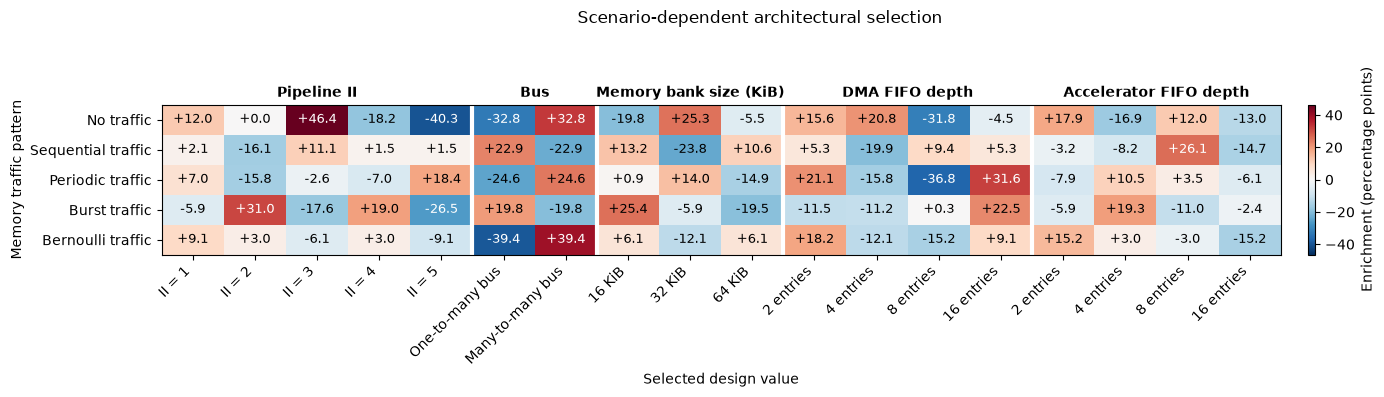

In [305]:
enrichment_columns = [
    "design.hls.pipeline_ii",
    "design.system.bus_type",
    "design.system.memory_bank_size_kib",
    "design.system.dma_fifo_depth",
    "design.system.accelerator_fifo_depth",
]

figure, ax, architectural_enrichment, last_generation_sizes = (
    plot_enrichment_heatmap(
    dataframes_best,
    dataframes,
    enrichment_columns,
    title="Scenario-dependent architectural selection",
    )
)

print("Last successful generation sizes:", last_generation_sizes)

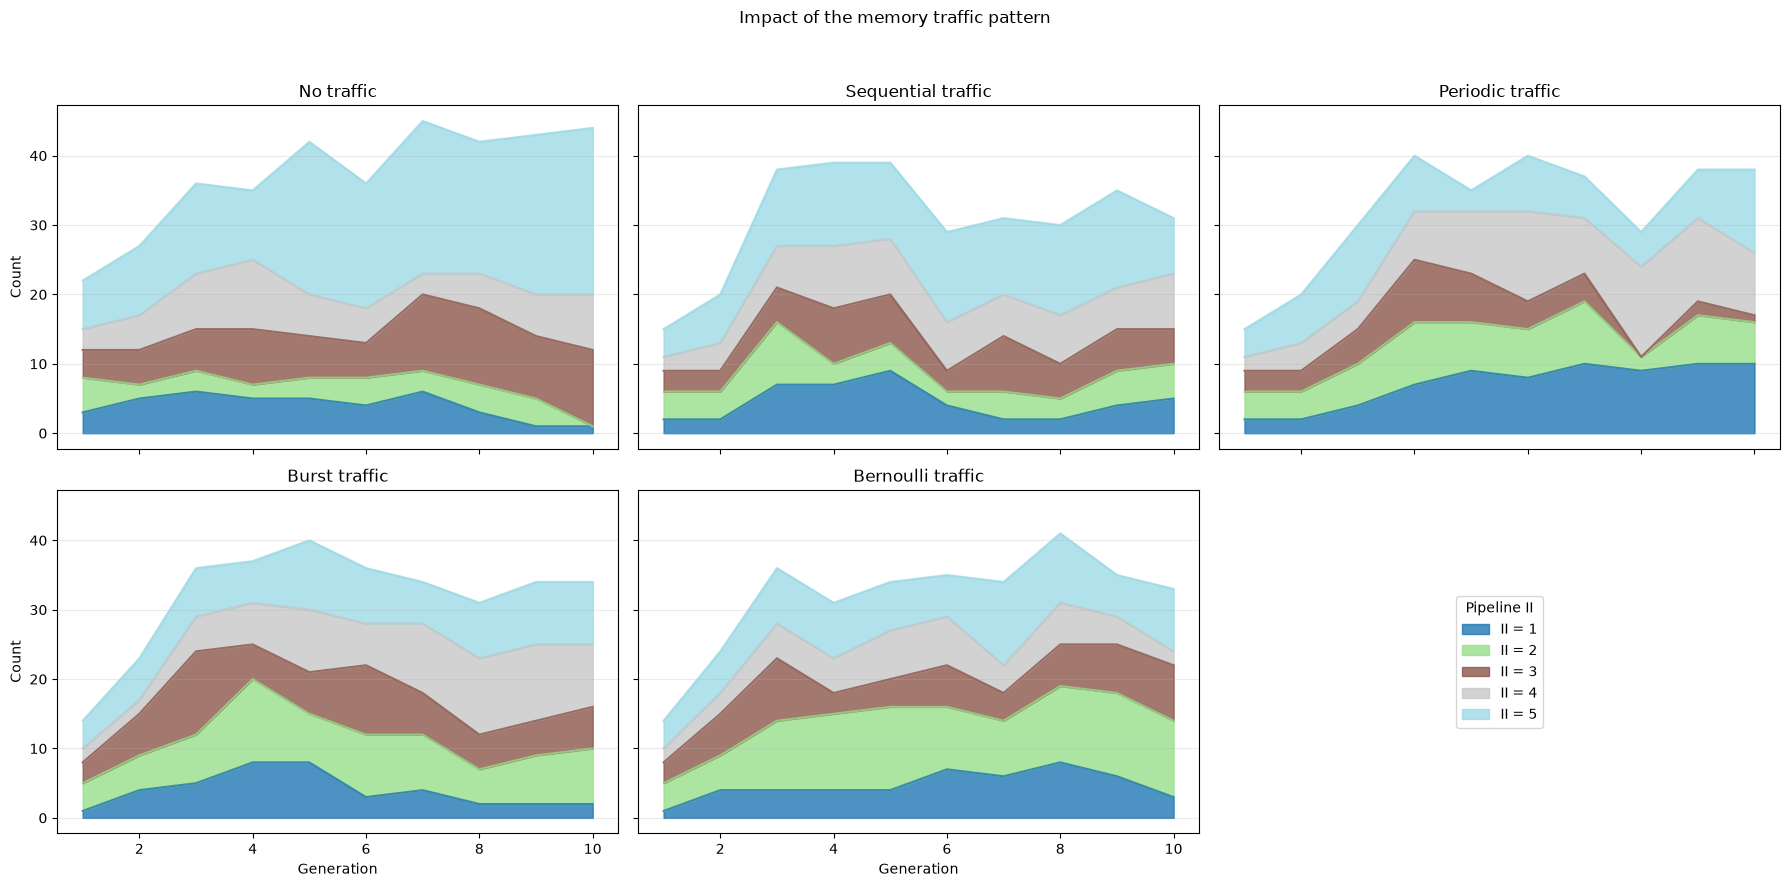

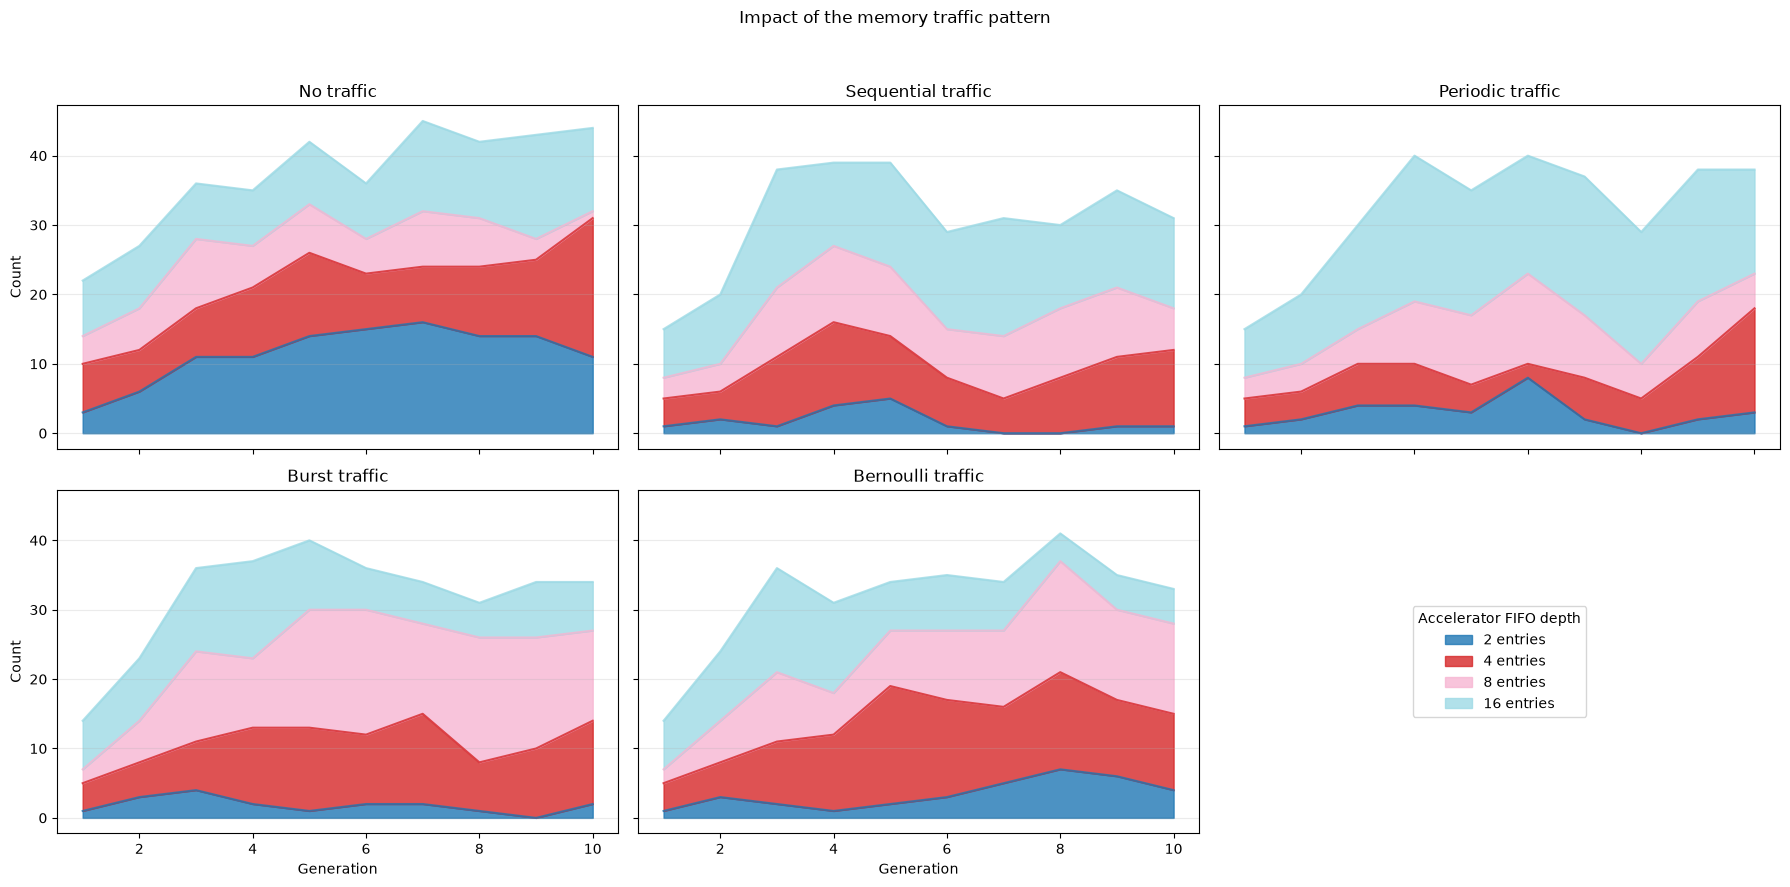

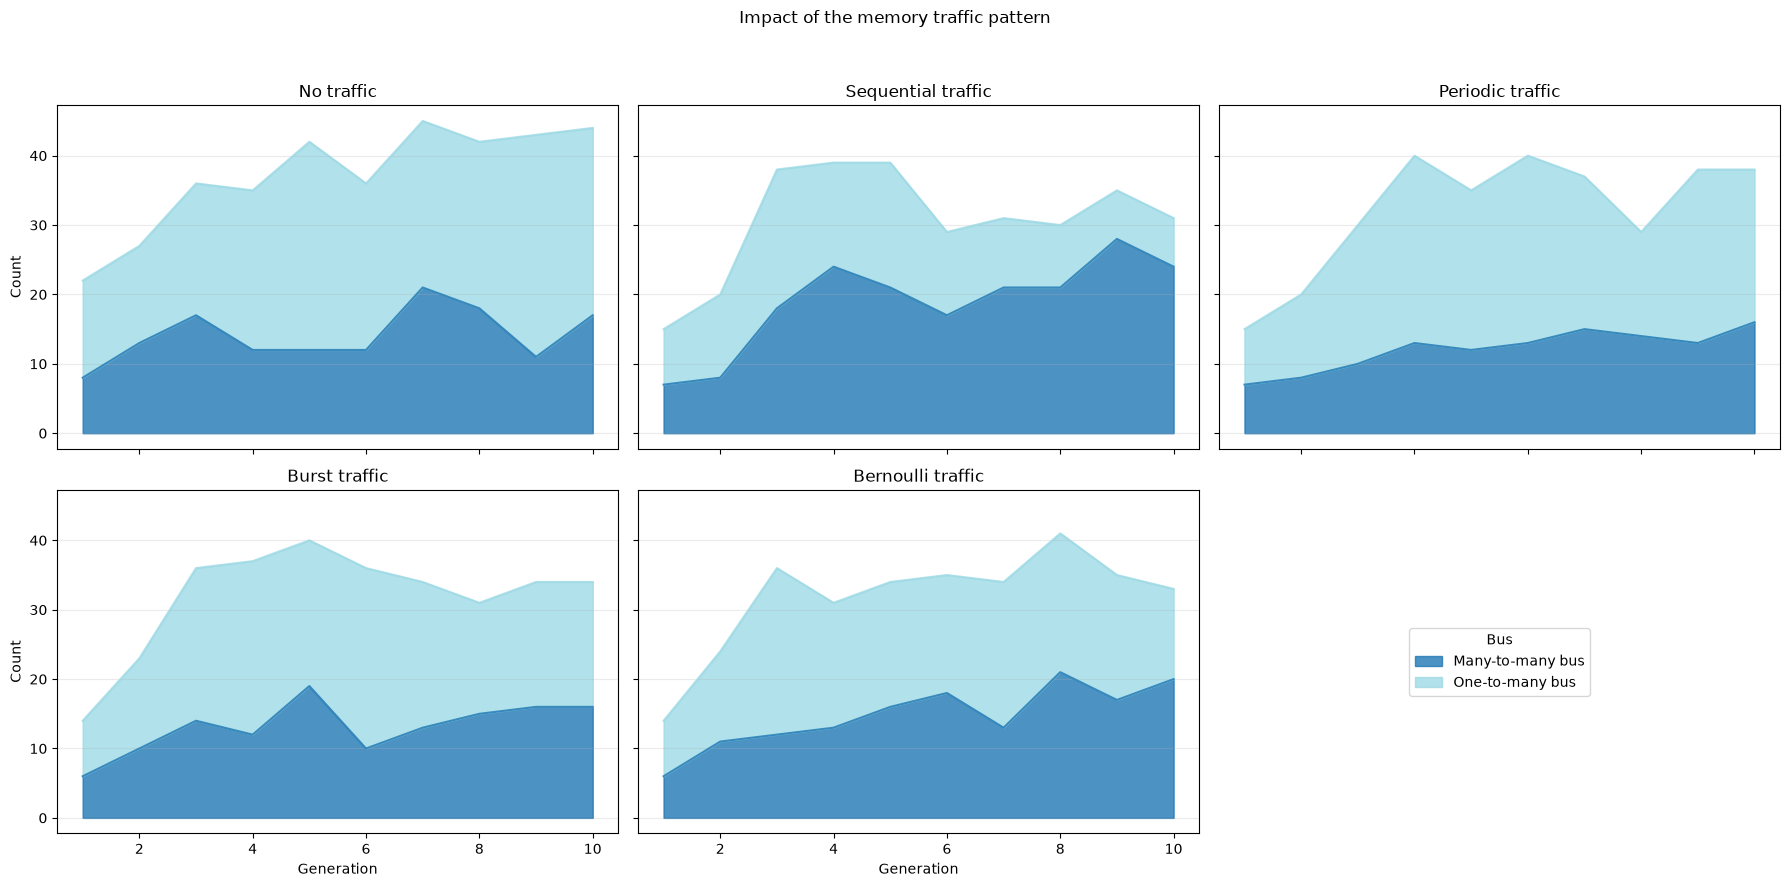

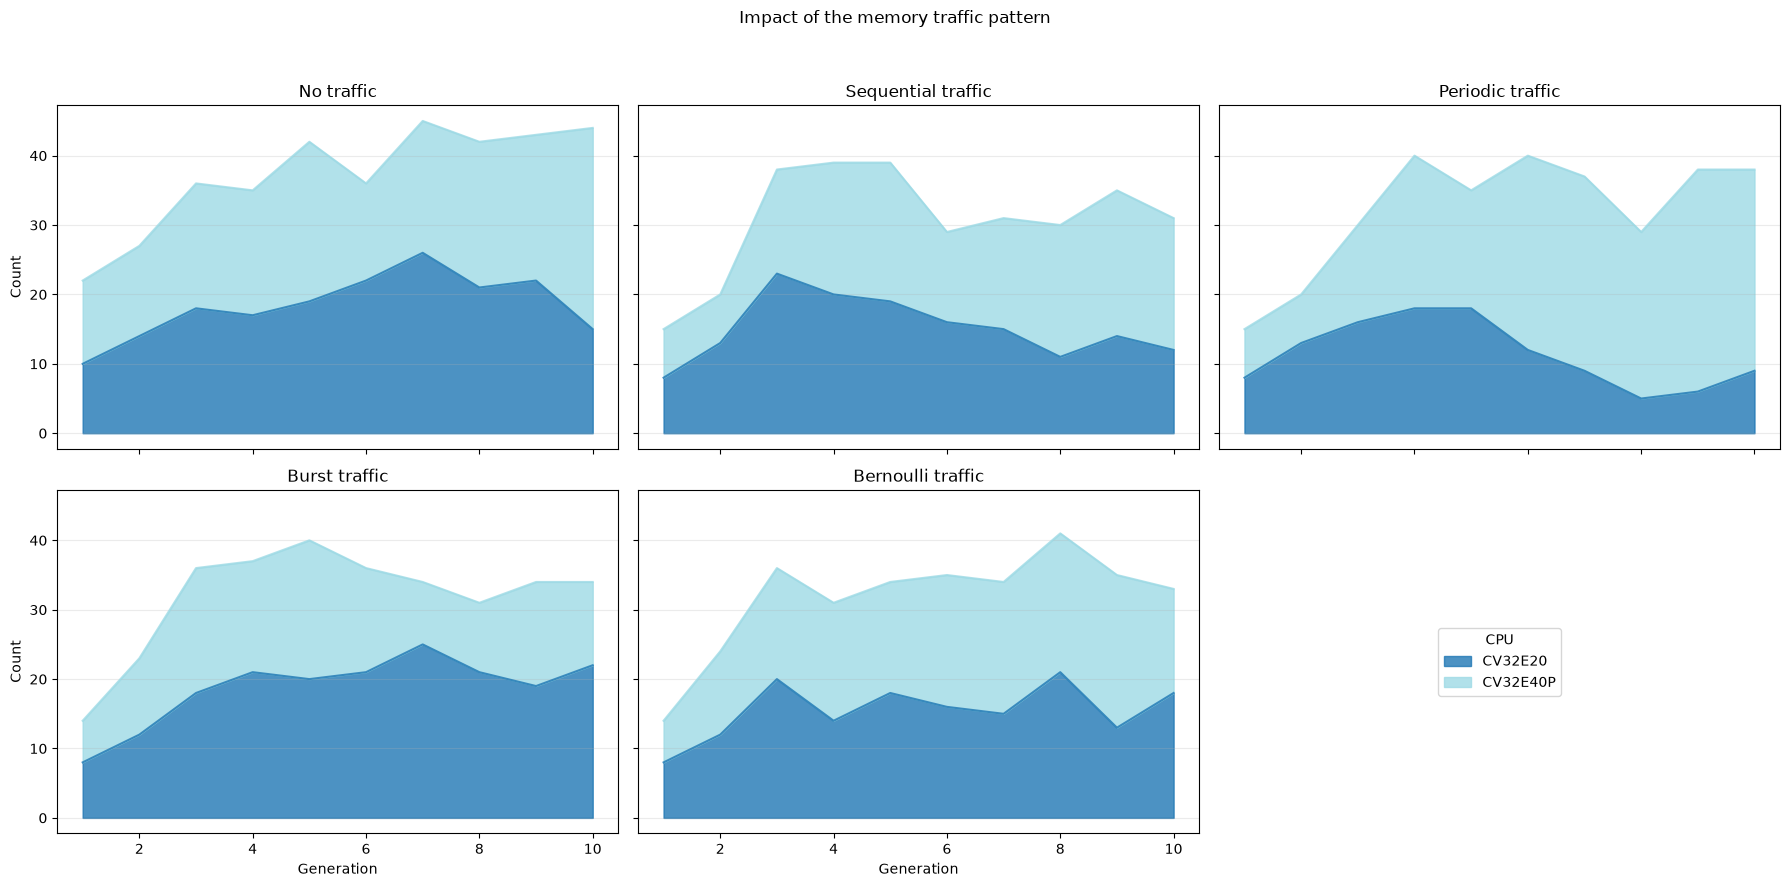

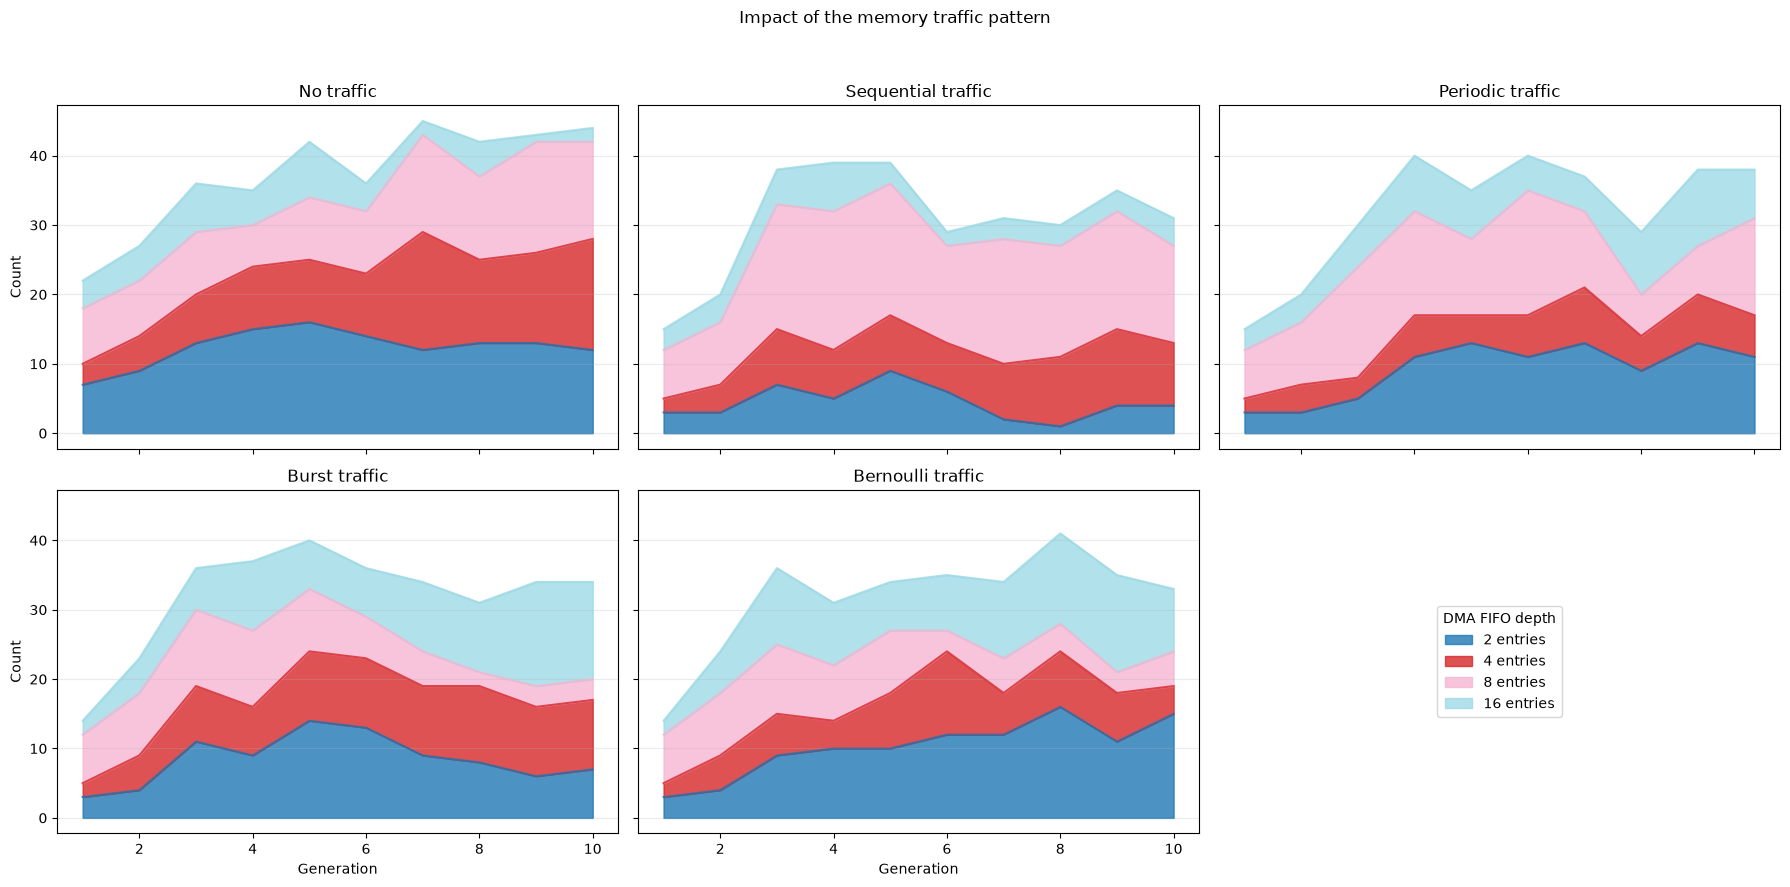

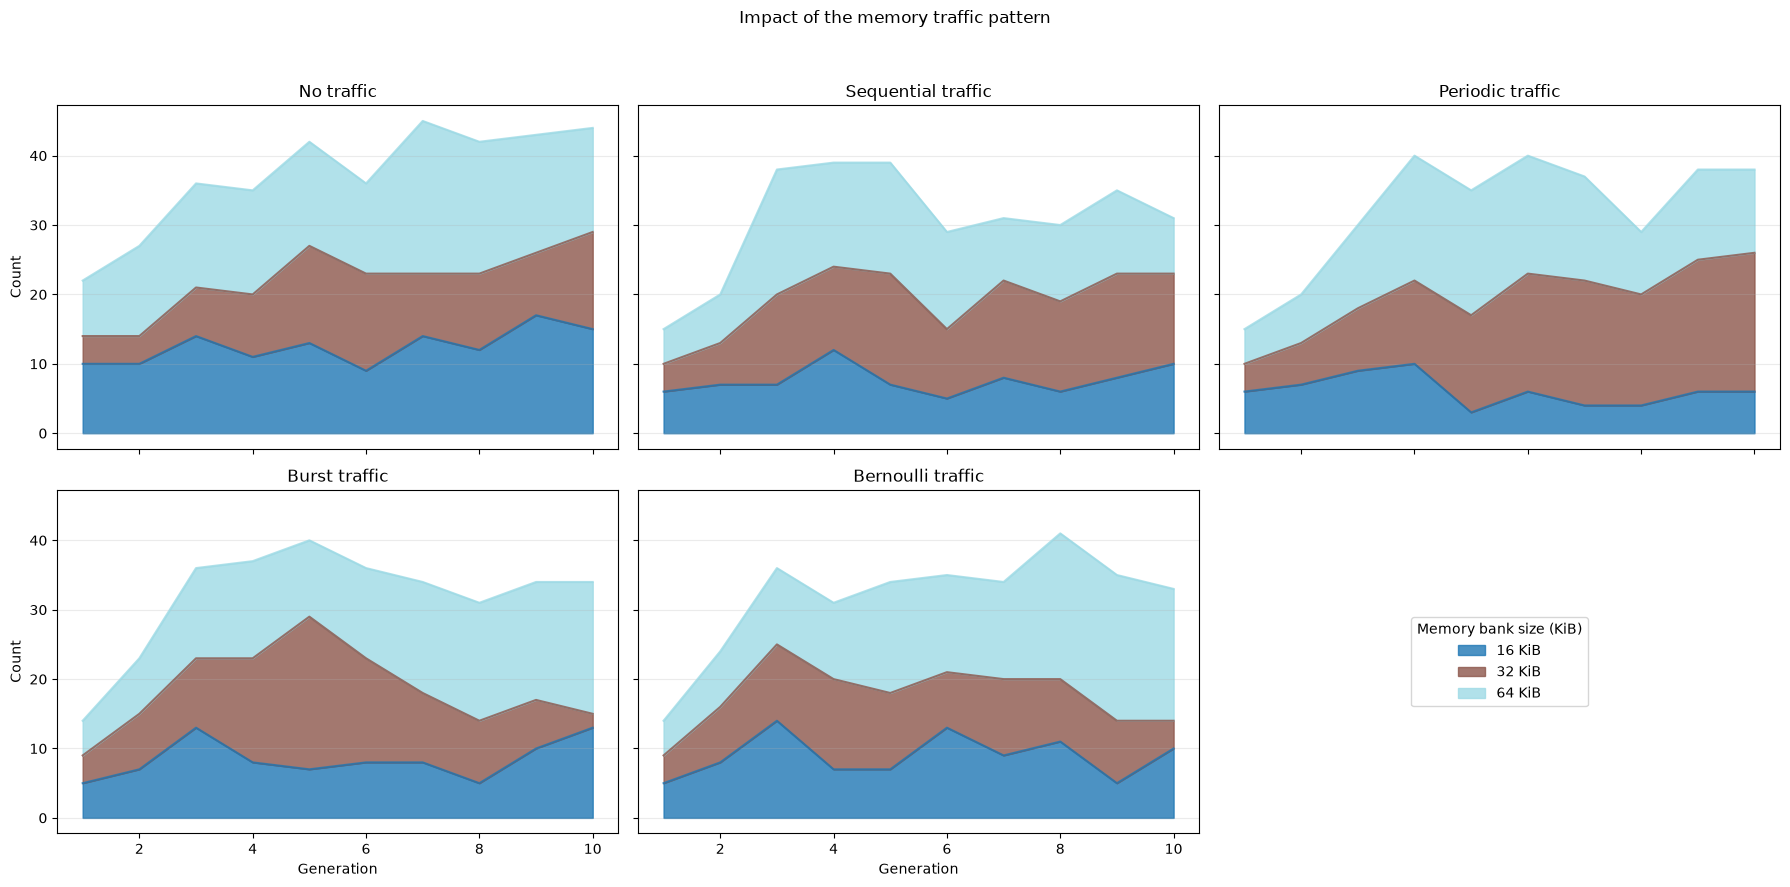

In [306]:
for column in design_columns:
    figure, axes = plot_stacked_counts_comparison(dataframes, column, title="Impact of the memory traffic pattern", ncols=3)

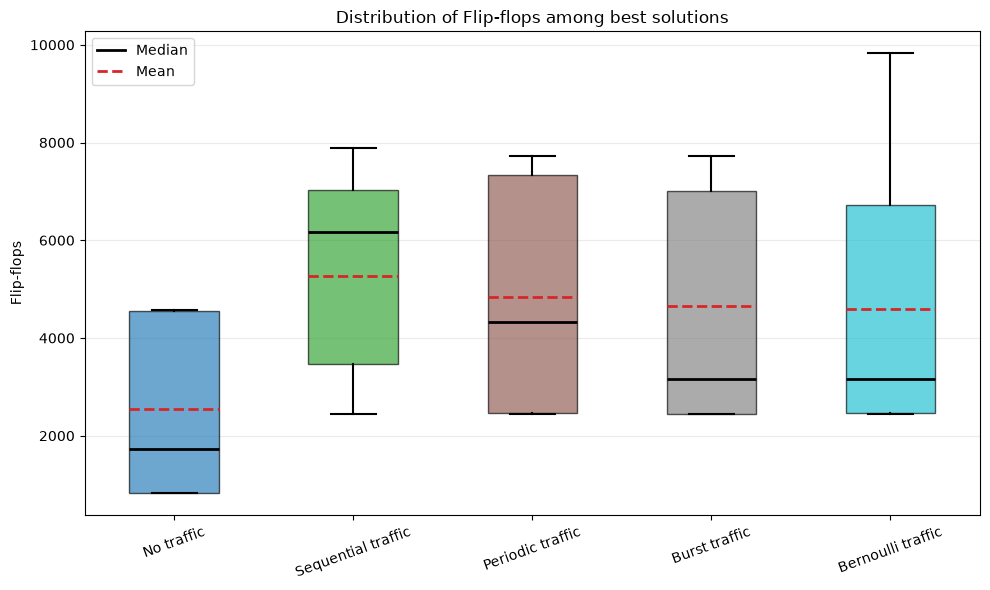

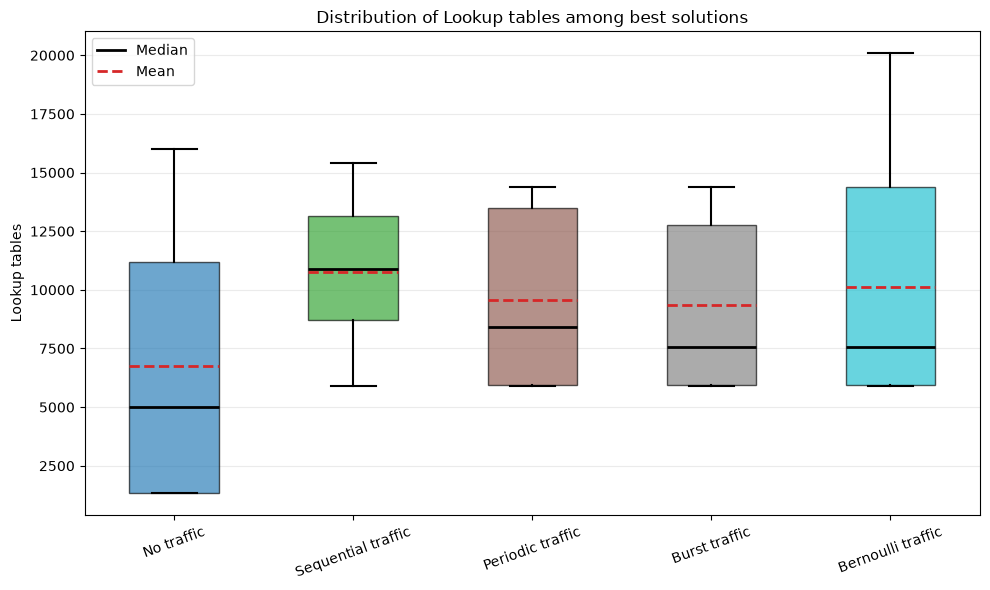

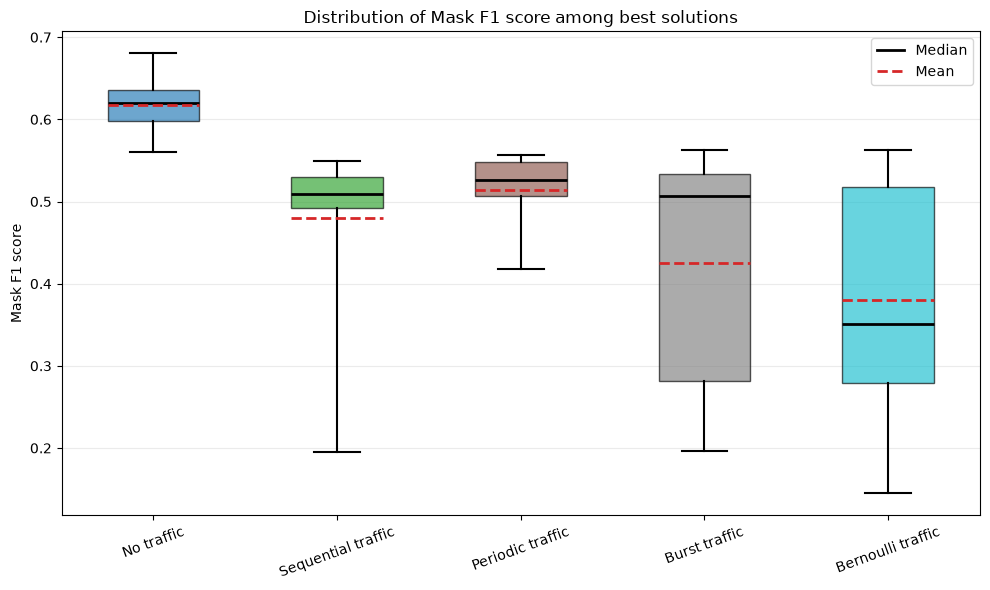

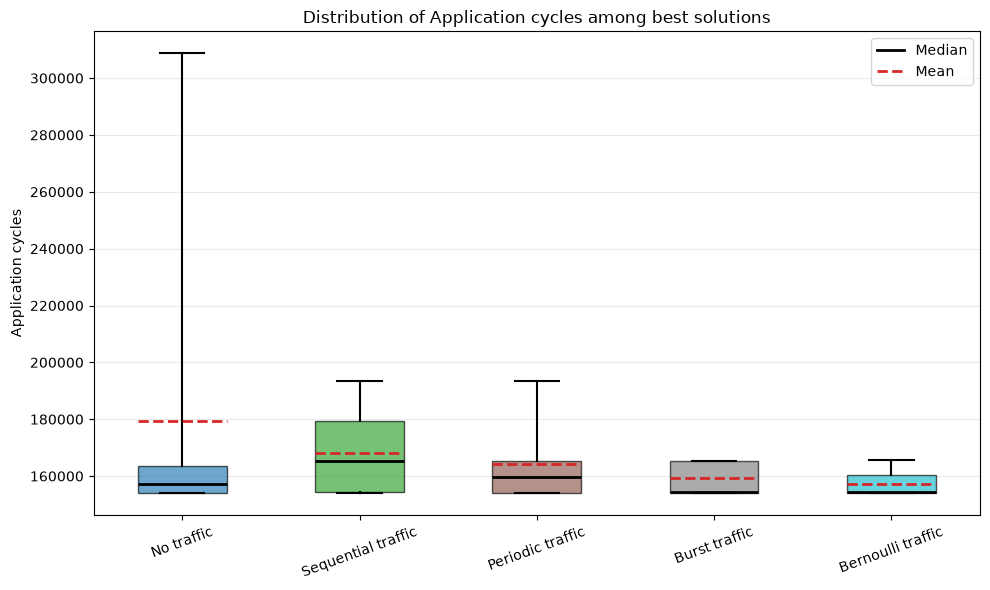

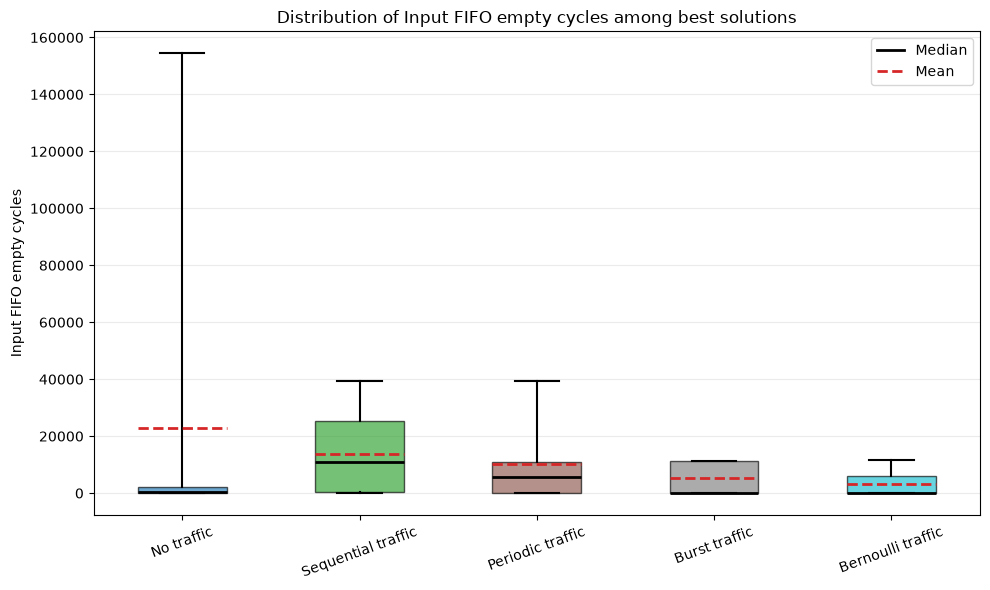

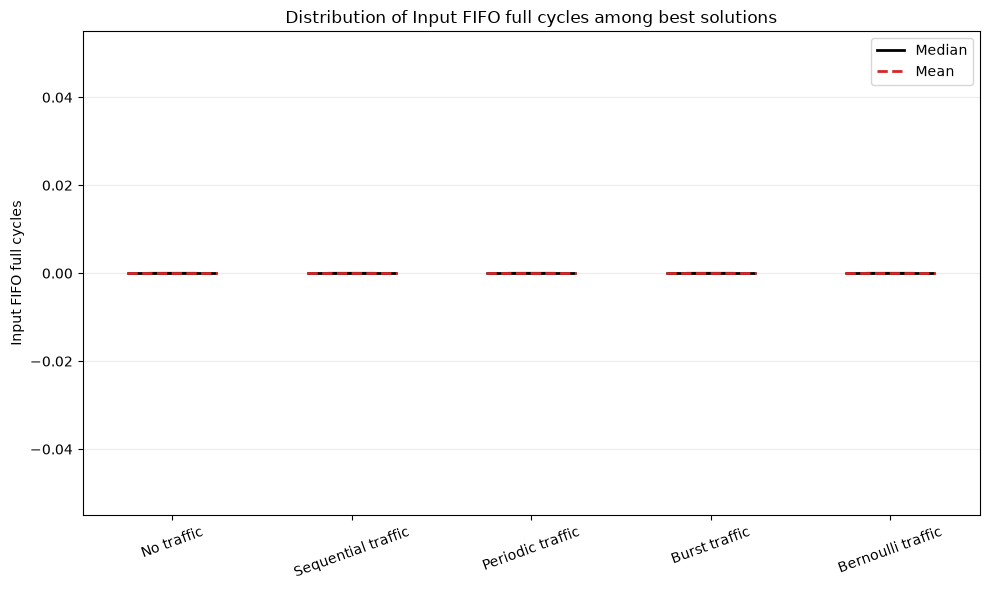

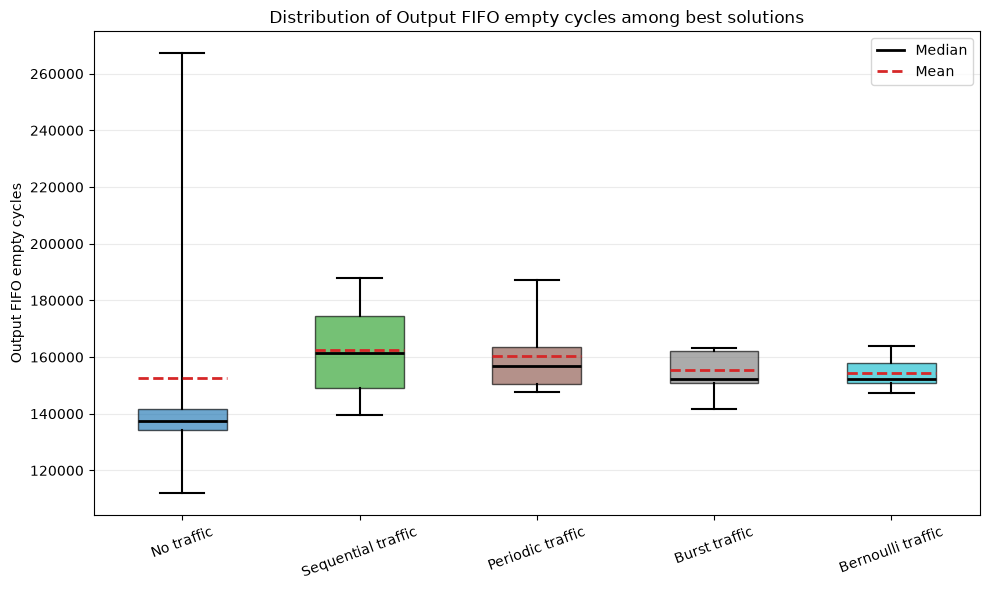

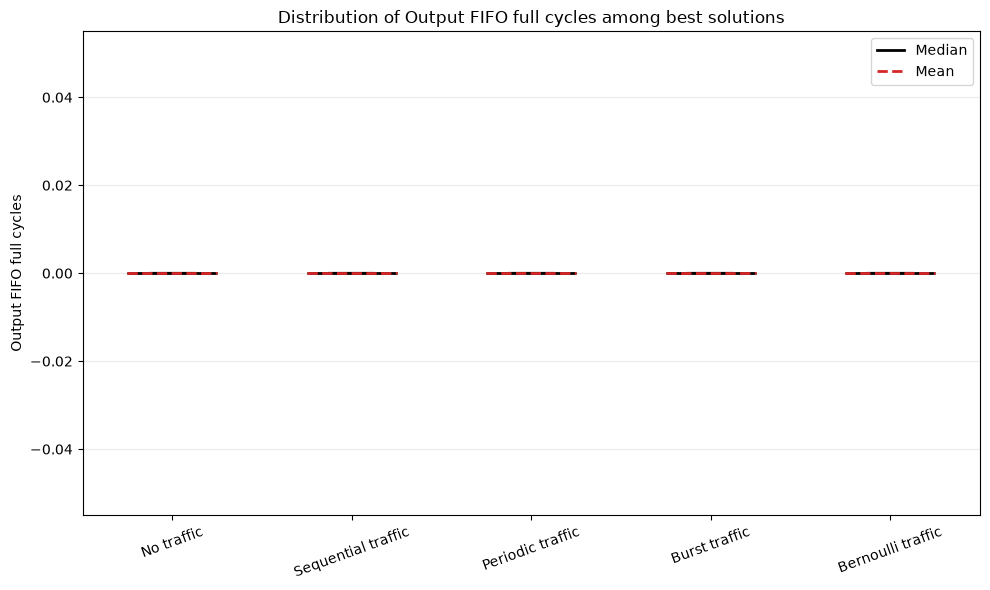

In [307]:
for column in objectives:
    figure, axes = plot_box_comparison(dataframes_best, column)

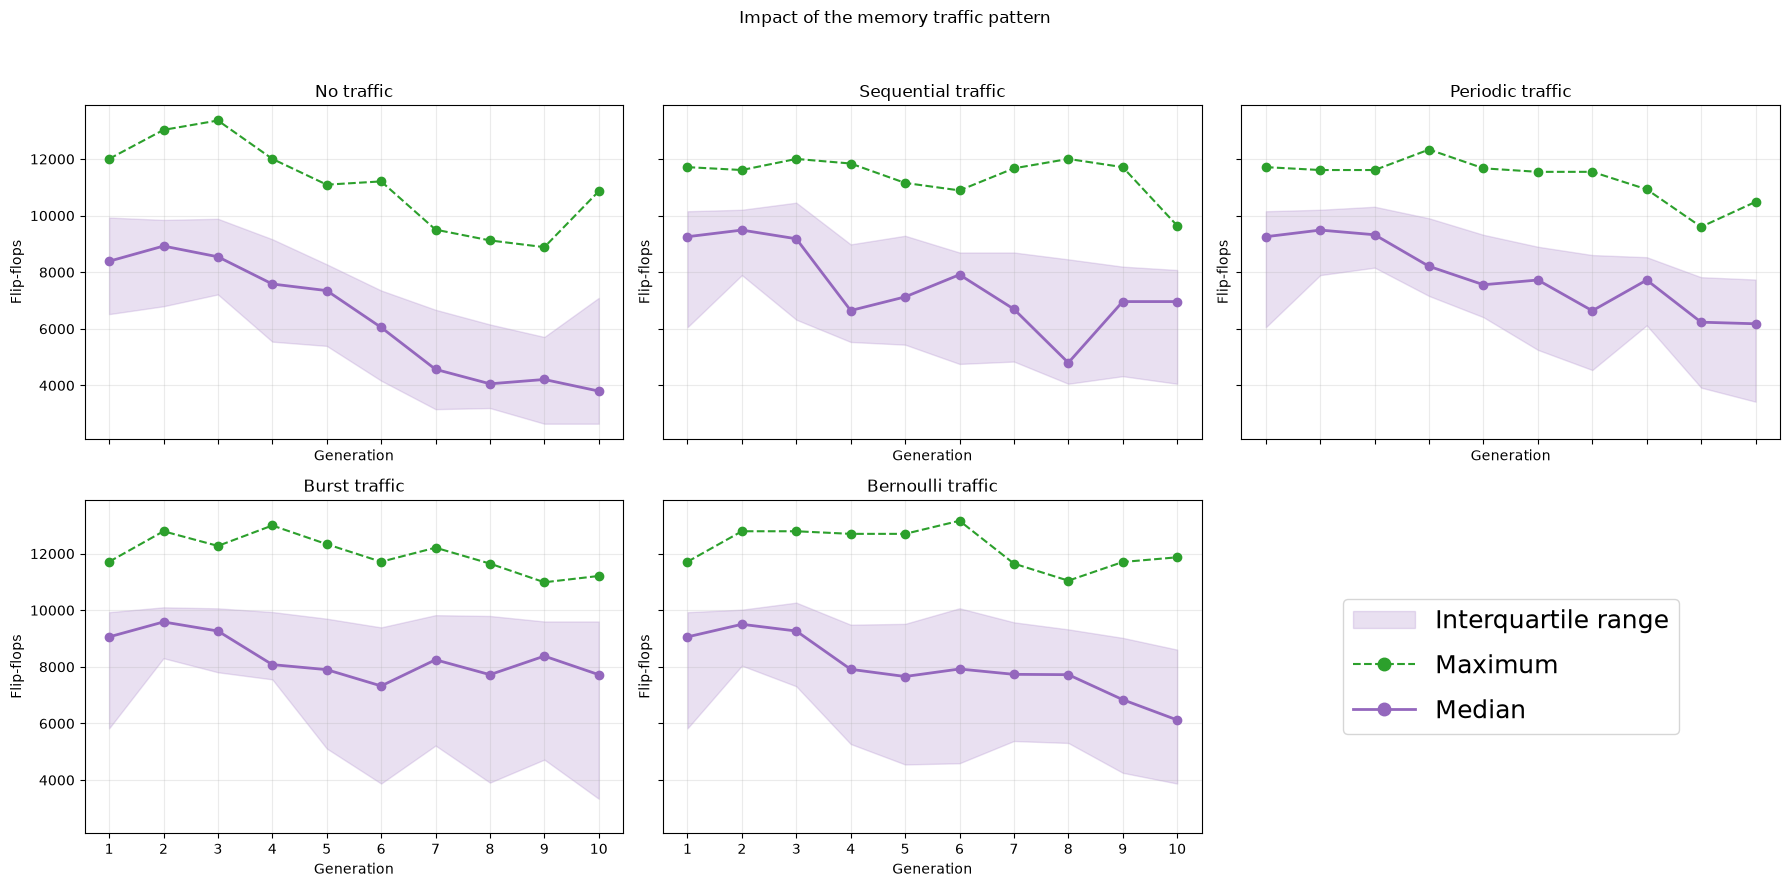

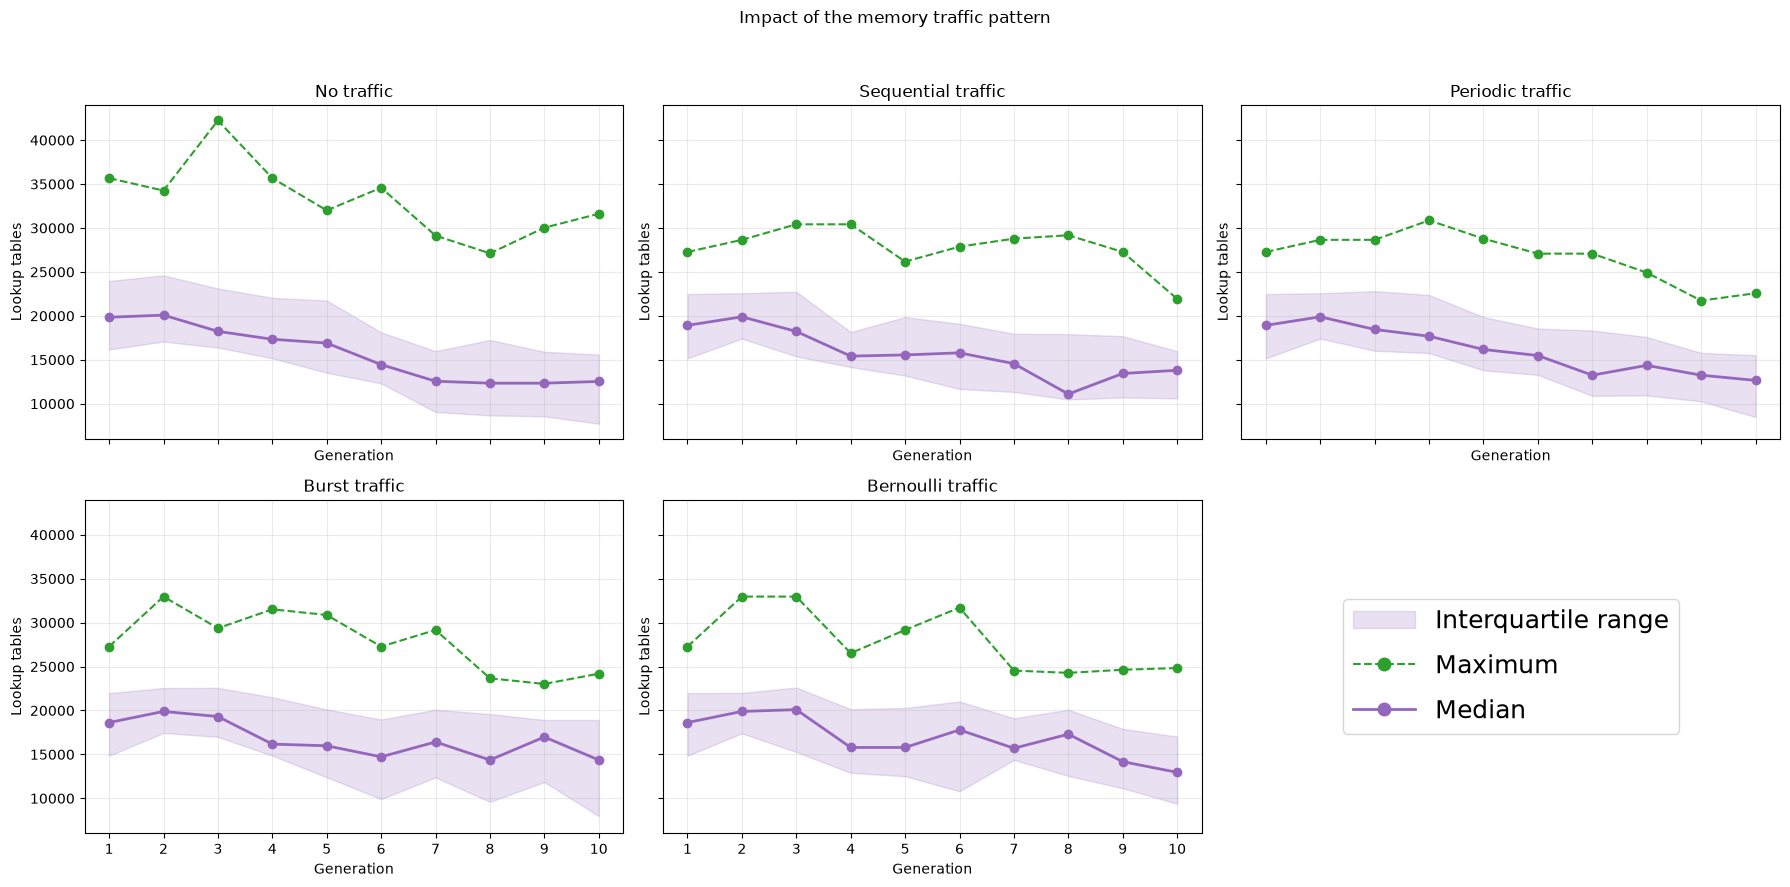

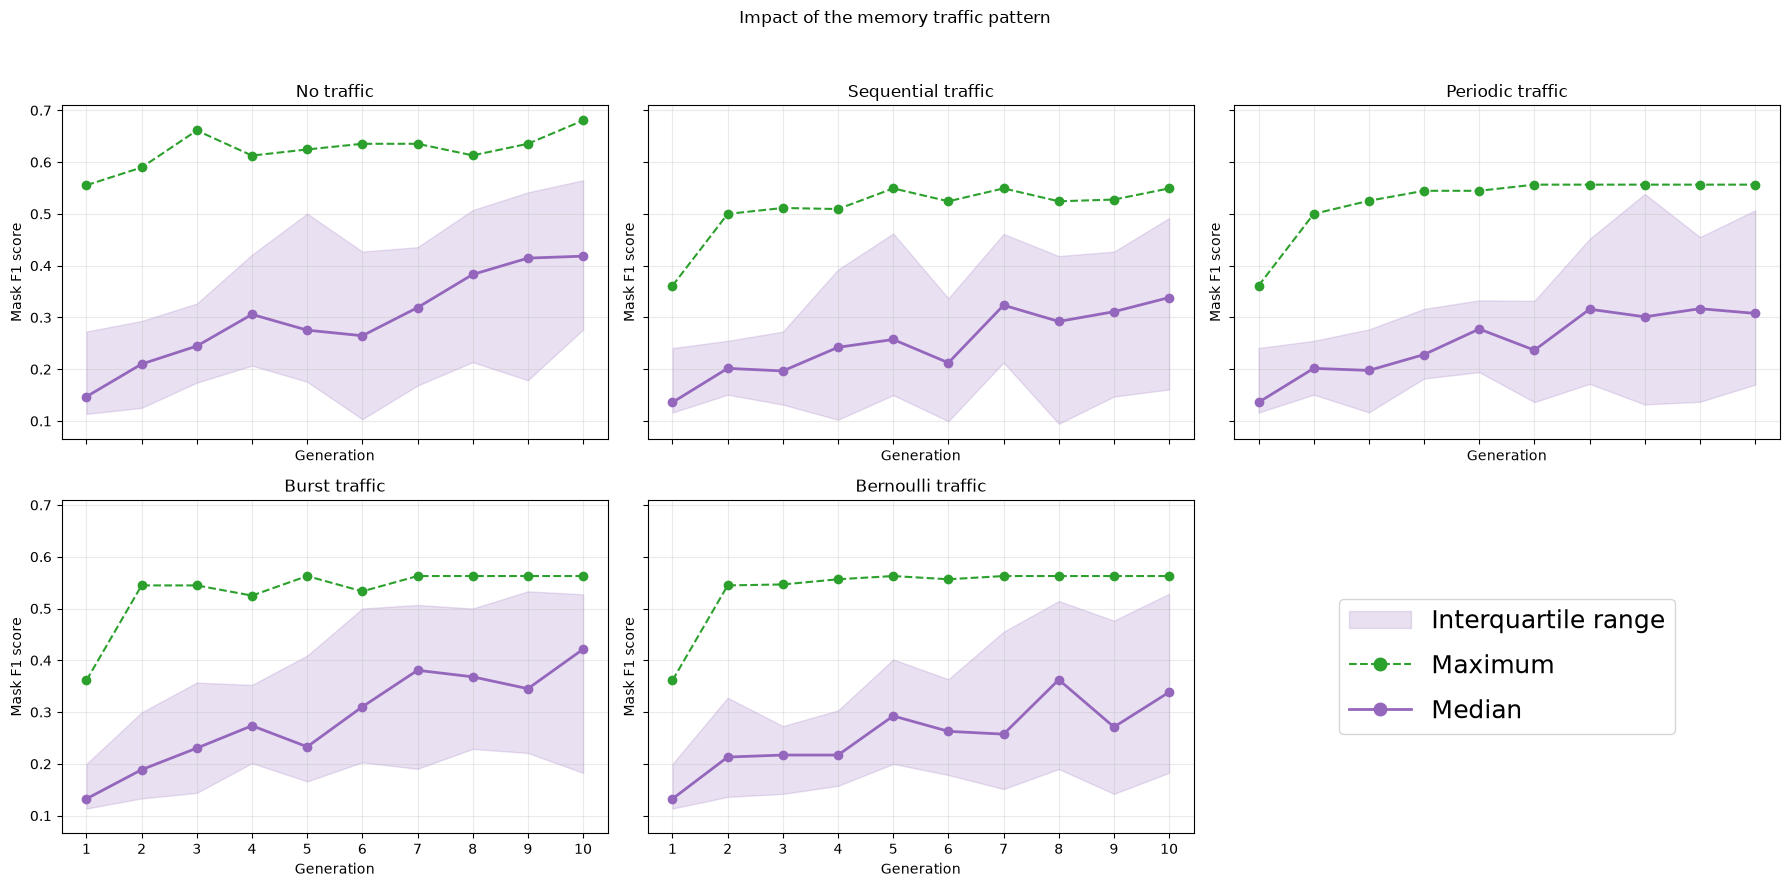

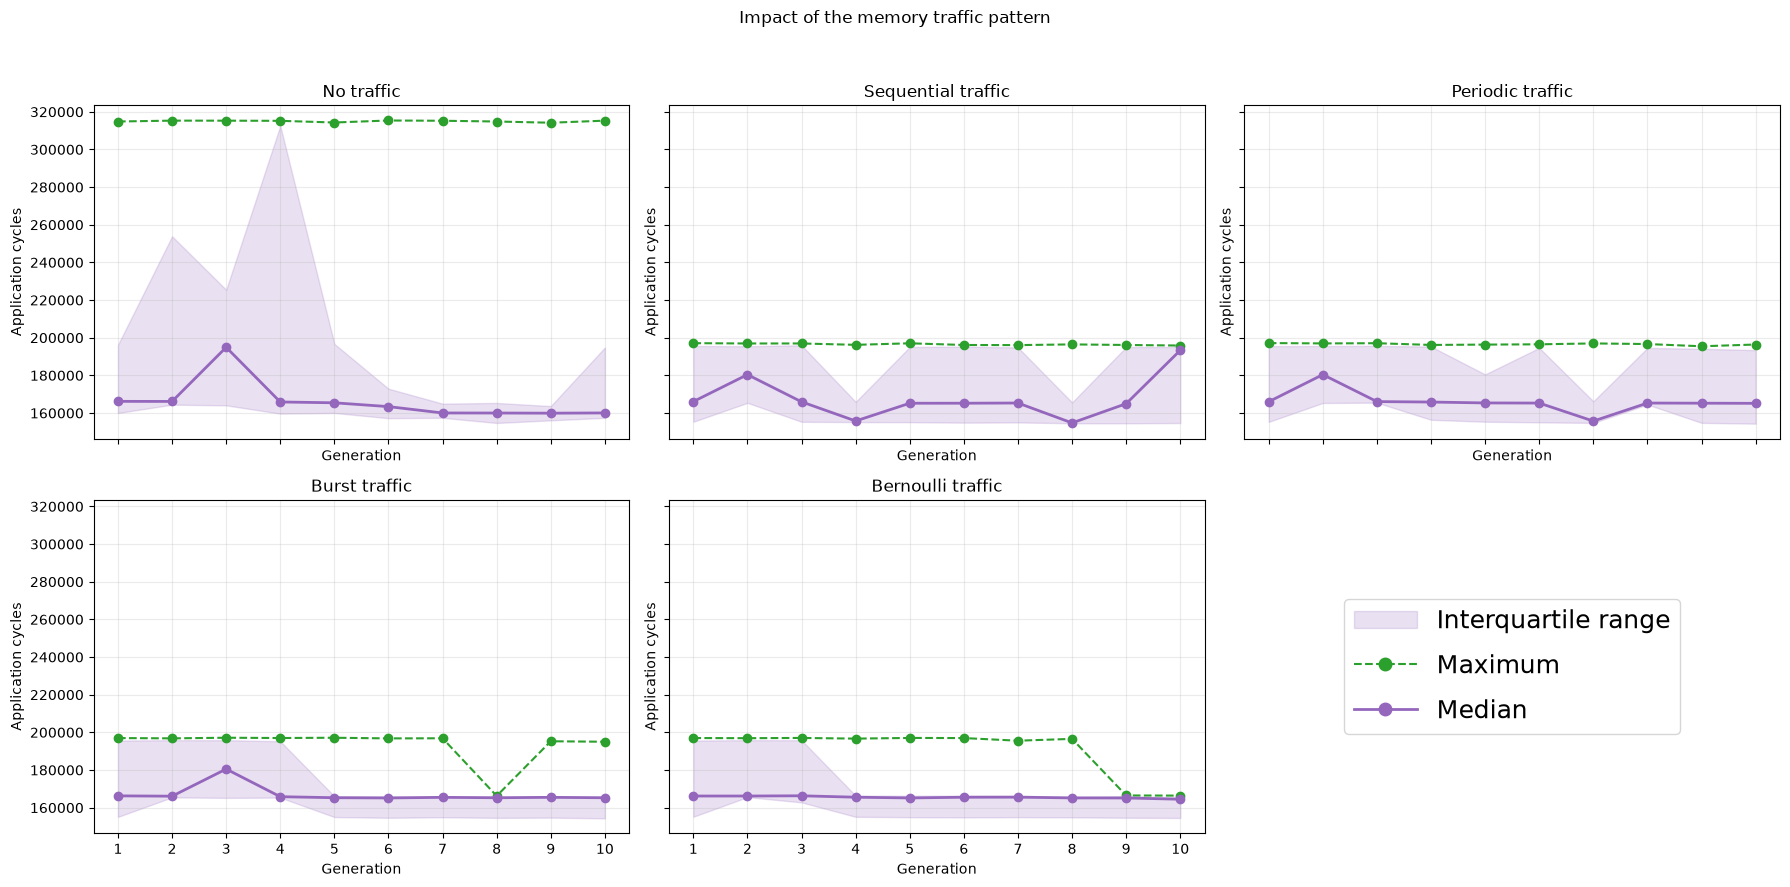

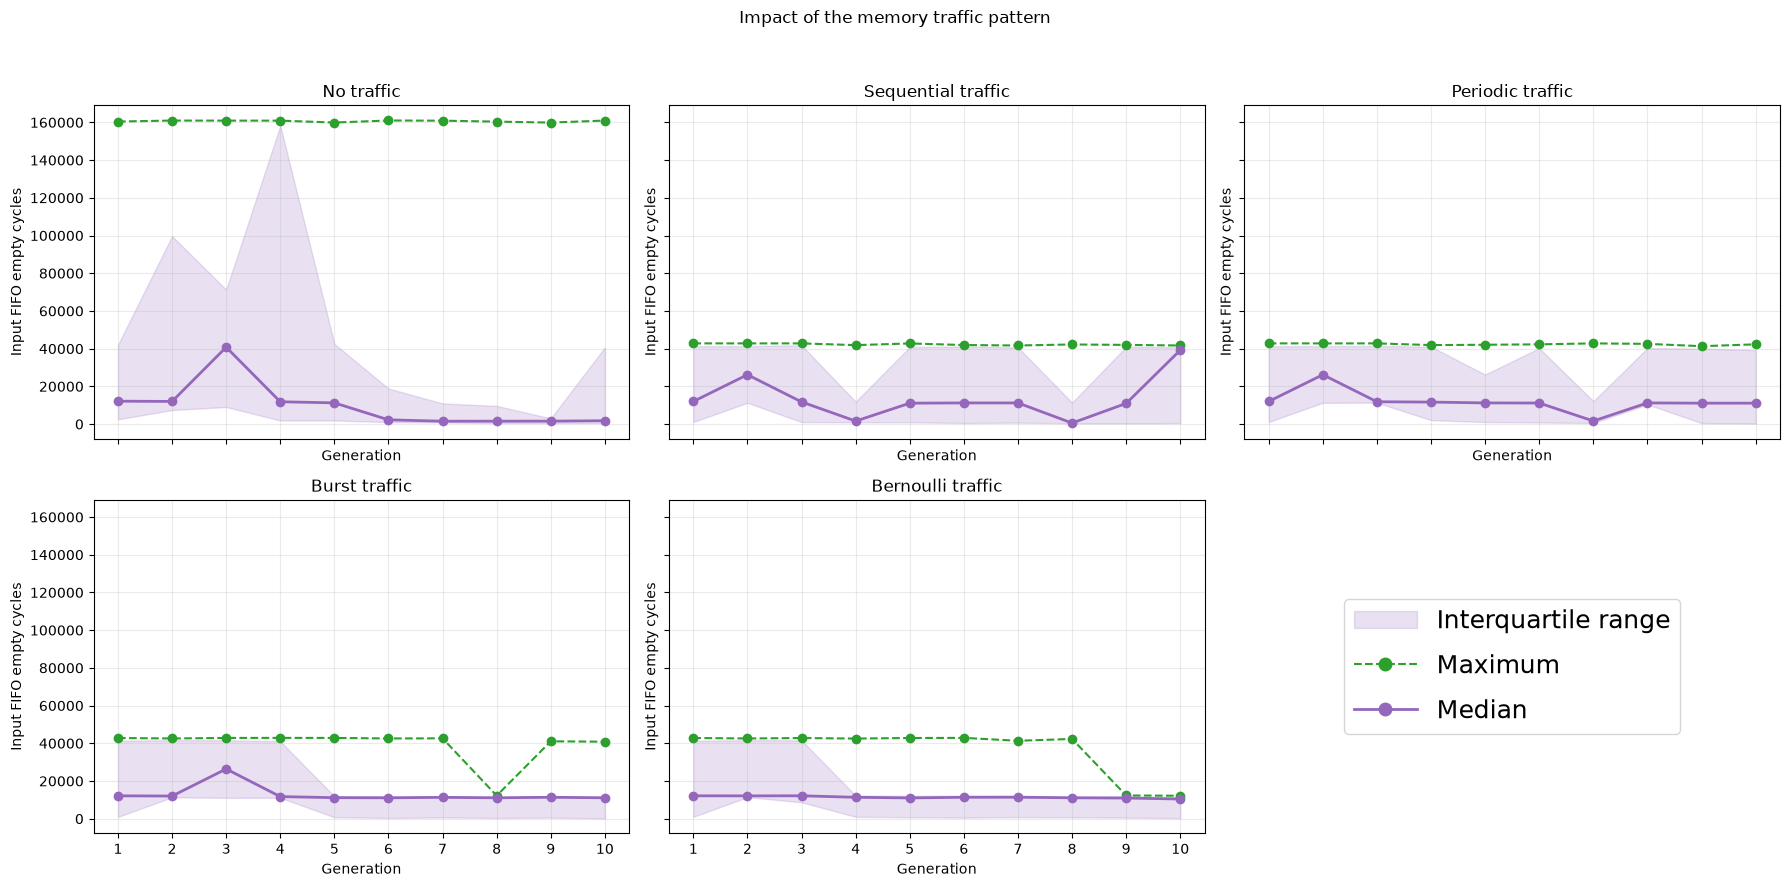

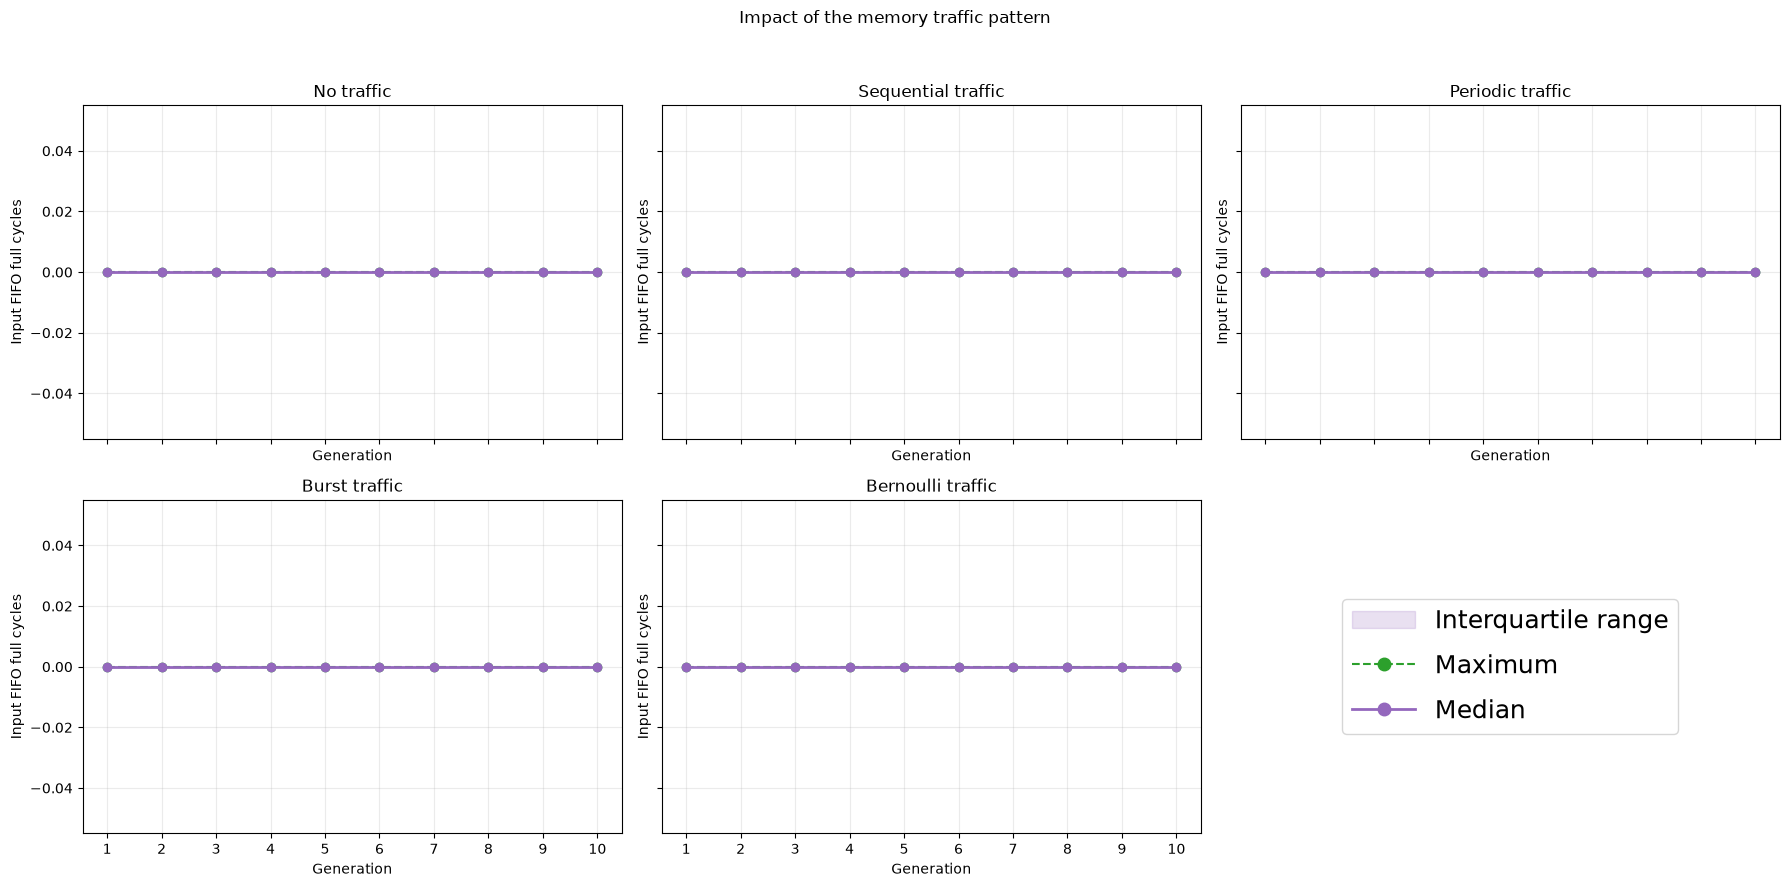

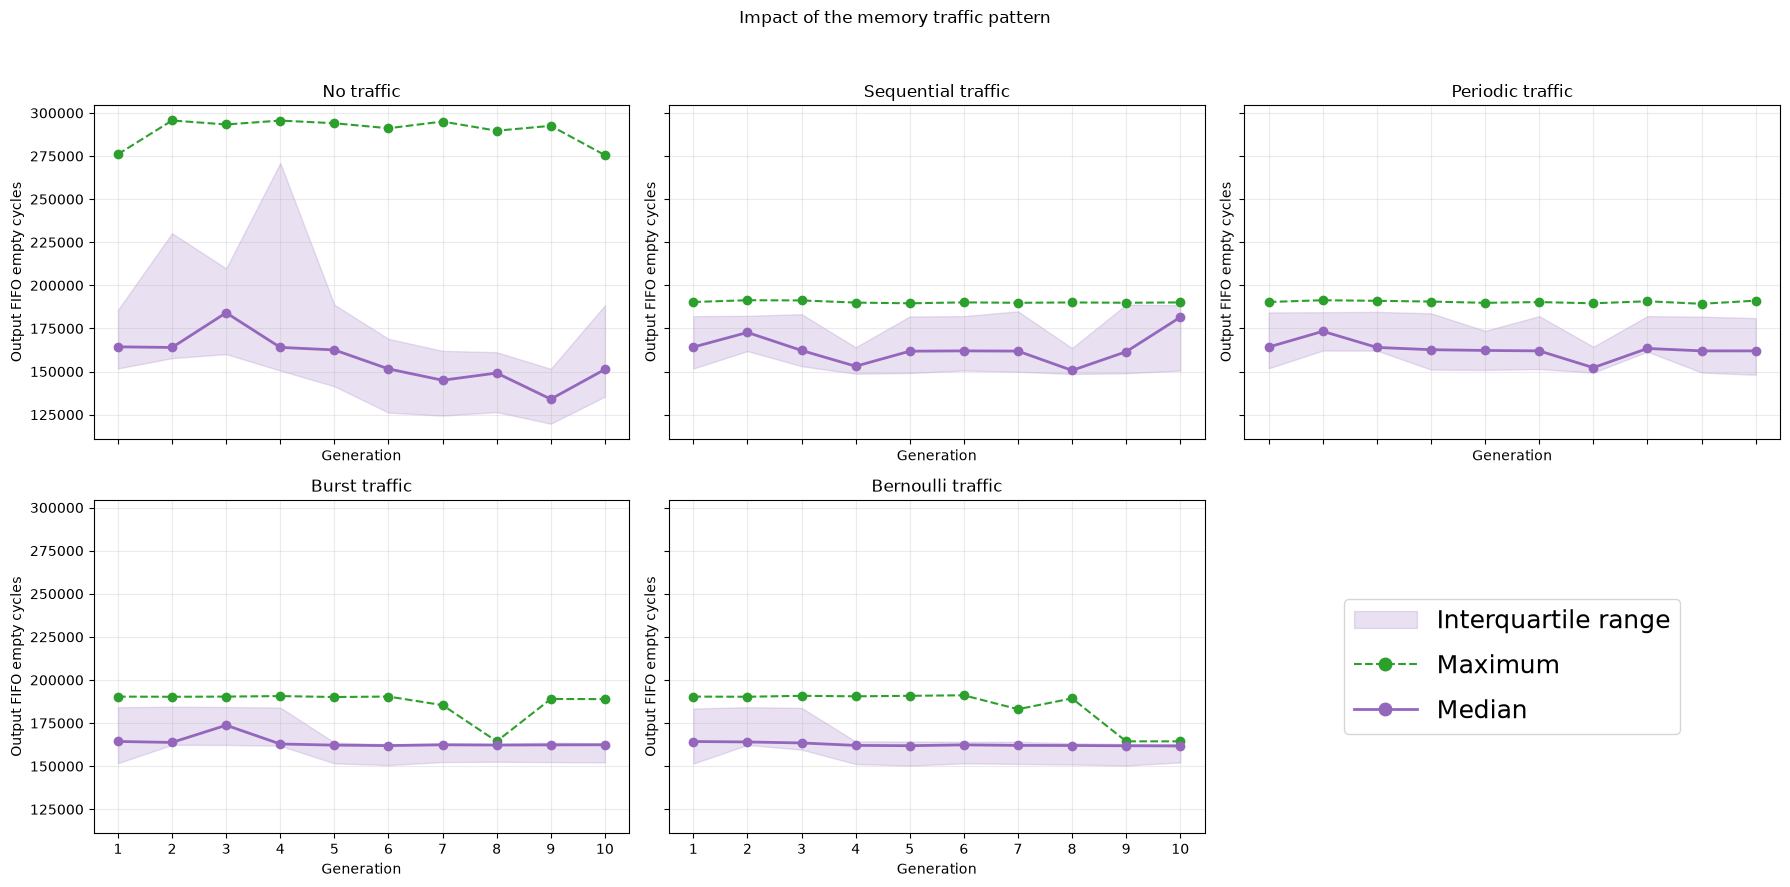

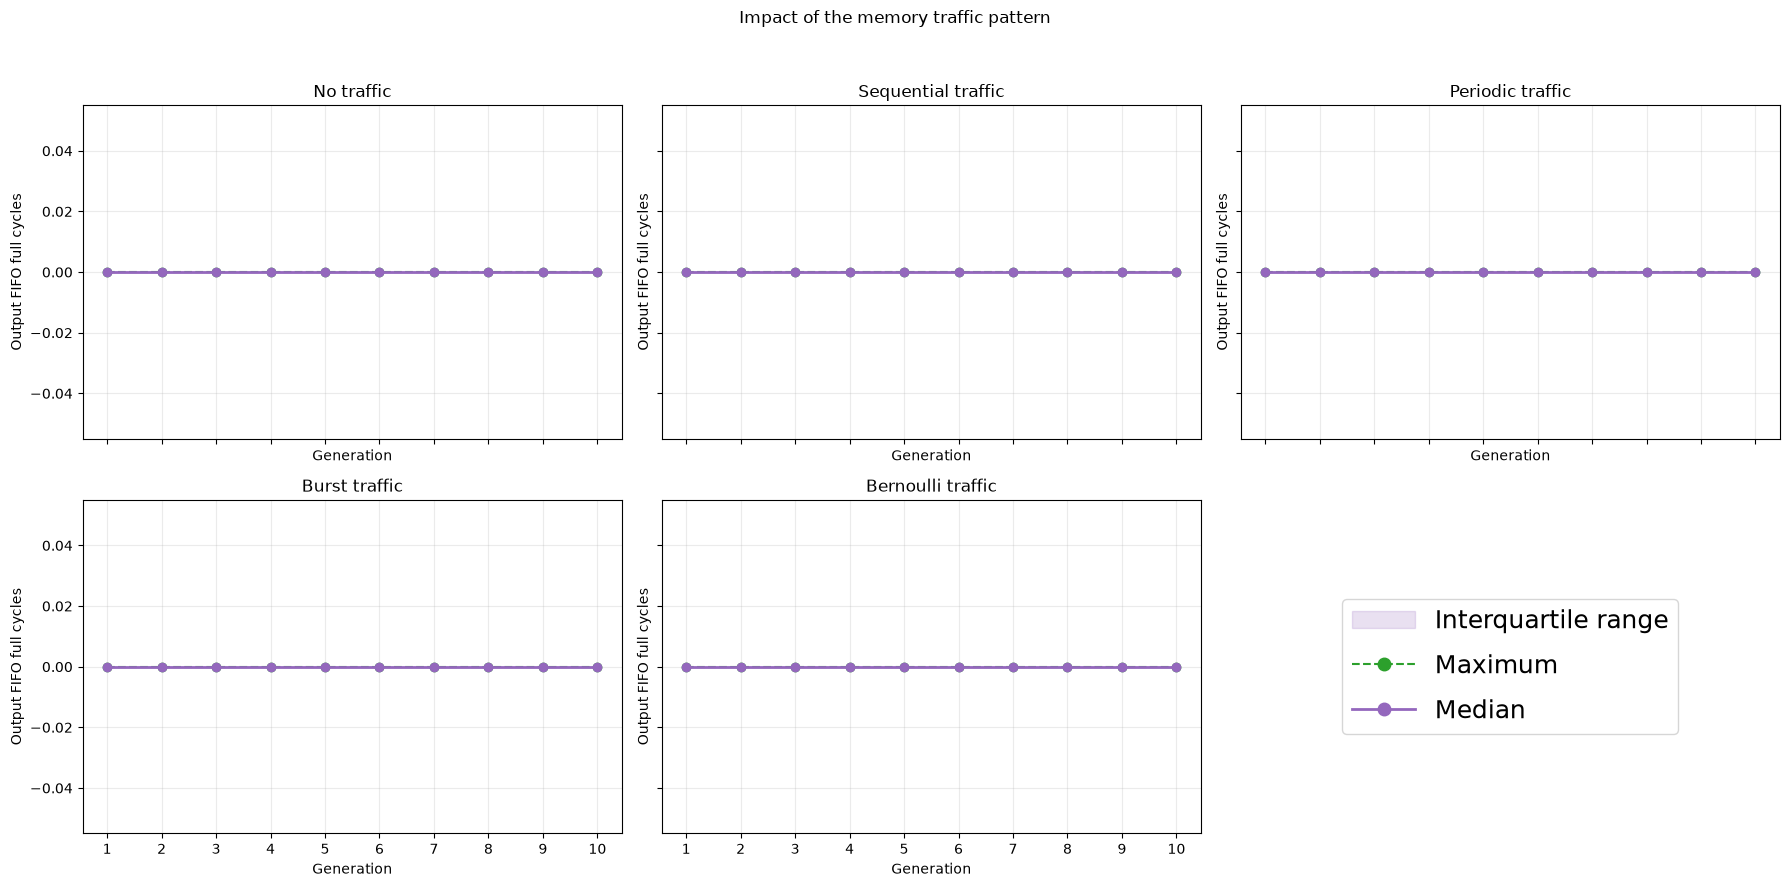

In [308]:
for column in objectives:
    figure, axes = plot_value_progression_comparison(dataframes, column, title="Impact of the memory traffic pattern", ncols=3, legend_fontsize=18)